# Deep Learning-Based Human Face Authenticity Detection
## EfficientNet-B2 Based Deepfake Detection Using Transfer Learning

---

## 📌 Project Overview

With the rapid advancement of Artificial Intelligence, generating highly realistic human faces and videos has become easier than ever. Modern deep learning techniques, particularly Generative Adversarial Networks (GANs) and Diffusion Models, are capable of producing synthetic facial media that closely resembles authentic content.

While these technologies have numerous beneficial applications, they are increasingly being exploited to create deepfakes for misinformation, identity theft, impersonation, digital fraud, and malicious social media manipulation.

This project aims to develop a robust deep learning-based framework capable of distinguishing between authentic and AI-generated human faces extracted from images and videos. The proposed system utilizes EfficientNet-B2 with transfer learning to classify facial images as **Real** or **Fake**.

---

# 🎯 Objectives

The primary objectives of this notebook are:

- Prepare a clean deepfake dataset suitable for deep learning.
- Extract representative frames from real and manipulated videos.
- Detect and crop facial regions from extracted frames.
- Perform preprocessing and data augmentation.
- Train an EfficientNet-B2 transfer learning model.
- Evaluate the model using standard classification metrics.
- Generate a baseline model for future improvements.

---

# 📂 Dataset Description

This project utilizes two benchmark datasets commonly used in deepfake detection research.

## Training Dataset

**FaceForensics++**

FaceForensics++ contains original videos along with manipulated versions generated using multiple deepfake techniques.

It will be used for:

- Training
- Validation
- Initial Testing

---

## External Testing Dataset

**Celeb-DF v2**

Celeb-DF v2 contains high-quality celebrity deepfake videos with fewer visual artifacts than FaceForensics++.

It will be used to evaluate the model's ability to generalize to unseen data.

# 📊 Exploratory Data Analysis (EDA)

Before training the model, it is important to understand the characteristics of the dataset.

The EDA performed in this notebook includes:

- Folder structure inspection
- Class distribution
- Sample visualization
- Image resolution analysis
- Dataset balance analysis

# 1. Install Required Libraries

## Objective
This section installs all the required libraries used throughout the project.

The project uses:

- **TensorFlow/Keras** – Deep Learning Framework
- **OpenCV** – Image Processing
- **RetinaFace** – Face Detection
- **Scikit-learn** – Data Splitting & Evaluation
- **Matplotlib & Seaborn** – Visualization
- **Pandas & NumPy** – Data Handling
- **Pillow** – Image Utilities

In [2]:

# RetinaFace for face detection
!pip install -q retina-face

# OpenCV (Headless version for Kaggle/Colab)
!pip install -q opencv-python-headless

# Image processing
!pip install -q pillow

# Visualization
!pip install -q seaborn

# Machine Learning utilities
!pip install -q scikit-learn

print("=" * 60)
print("✅ All required libraries installed successfully.")
print("=" * 60)

✅ All required libraries installed successfully.


# 2. Import Required Libraries

## Objective

This section imports all the libraries required for data handling, visualization, image preprocessing, face detection, deep learning, evaluation, and model explainability.

The libraries are grouped into the following categories:

- Standard Python Libraries
- Data Manipulation
- Visualization
- Image Processing
- Face Detection
- TensorFlow / Keras
- Data Augmentation
- Model Evaluation
- Utility Functions

Keeping imports organized makes the notebook easier to maintain and avoids duplicate imports.

In [3]:

import os
import random
import shutil
import warnings
from pathlib import Path

# -----------------------------
# Numerical & Data Handling
# -----------------------------
import numpy as np
import pandas as pd

# -----------------------------
# Visualization
# -----------------------------
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# Image Processing
# -----------------------------
import cv2
from PIL import Image

# -----------------------------
# Face Detection
# -----------------------------
from retinaface import RetinaFace

# -----------------------------
# TensorFlow & Keras
# -----------------------------
import tensorflow as tf

from tensorflow.keras import Model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Dense,
    Dropout,
    BatchNormalization,
    GlobalAveragePooling2D
)

from tensorflow.keras.applications import EfficientNetB2
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

from tensorflow.keras.optimizers import Adam

# -----------------------------
# Dataset Splitting
# -----------------------------
from sklearn.model_selection import train_test_split

# -----------------------------
# Evaluation Metrics
# -----------------------------
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report
)

# -----------------------------
# Class Weight Calculation
# -----------------------------
from sklearn.utils.class_weight import compute_class_weight

# -----------------------------
# Ignore Warnings
# -----------------------------
warnings.filterwarnings("ignore")

# -----------------------------
# Set Plot Style
# -----------------------------
plt.style.use("ggplot")
sns.set_style("whitegrid")

print("=" * 60)
print("✅ All libraries imported successfully.")
print("=" * 60)

✅ All libraries imported successfully.


# 3. Set Hyperparameters

## Objective

This section defines all configurable hyperparameters used throughout the notebook.

Keeping all parameters in one place makes the notebook easy to modify and reproduce.

The hyperparameters include:

- Image Size
- Batch Size
- Number of Epochs
- Learning Rates
- Random Seed
- Dataset Split Ratio
- Number of Fine-tuning Layers
- Number of Output Classes

These values can be changed later without modifying the rest of the notebook.

In [4]:

# Image Parameters
# ----------------------------------------------------------
IMAGE_SIZE = (224, 224)
CHANNELS = 3

# ----------------------------------------------------------
# Dataset Parameters
# ----------------------------------------------------------
BATCH_SIZE = 32
NUM_CLASSES = 1          # Binary Classification (Real / Fake)

# Dataset Split
TRAIN_SPLIT = 0.70
VALID_SPLIT = 0.15
TEST_SPLIT = 0.15

# ----------------------------------------------------------
# Training Parameters
# ----------------------------------------------------------
EPOCHS_STAGE1 = 10        # Frozen Backbone
EPOCHS_STAGE2 = 10        # Fine-Tuning

# ----------------------------------------------------------
# Learning Rates
# ----------------------------------------------------------
LEARNING_RATE = 1e-3
FINE_TUNE_LR = 1e-5

# ----------------------------------------------------------
# Fine-Tuning Parameters
# ----------------------------------------------------------
UNFREEZE_LAST_LAYERS = 40

# ----------------------------------------------------------
# Regularization
# ----------------------------------------------------------
DROPOUT_RATE = 0.30

# ----------------------------------------------------------
# Random Seed
# ----------------------------------------------------------
SEED = 42

# ----------------------------------------------------------
# Face Detection
# ----------------------------------------------------------
FACE_DETECTION_CONFIDENCE = 0.90

# ----------------------------------------------------------
# Model Save Paths
# ----------------------------------------------------------
BEST_MODEL_PATH = "EfficientNetB2_Best.keras"
FINAL_MODEL_PATH = "EfficientNetB2_Final.keras"

# ----------------------------------------------------------
# Input Shape
# ----------------------------------------------------------
INPUT_SHAPE = IMAGE_SIZE + (CHANNELS,)

# ----------------------------------------------------------
# Set Random Seeds for Reproducibility
# ----------------------------------------------------------
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("=" * 60)
print("Project Hyperparameters")
print("=" * 60)

print(f"Image Size              : {IMAGE_SIZE}")
print(f"Batch Size              : {BATCH_SIZE}")
print(f"Stage-1 Epochs          : {EPOCHS_STAGE1}")
print(f"Stage-2 Epochs          : {EPOCHS_STAGE2}")
print(f"Learning Rate           : {LEARNING_RATE}")
print(f"Fine-Tune LR            : {FINE_TUNE_LR}")
print(f"Fine-Tune Layers        : Last {UNFREEZE_LAST_LAYERS}")
print(f"Dropout Rate            : {DROPOUT_RATE}")
print(f"Train Split             : {TRAIN_SPLIT:.0%}")
print(f"Validation Split        : {VALID_SPLIT:.0%}")
print(f"Test Split              : {TEST_SPLIT:.0%}")
print(f"Random Seed             : {SEED}")
print(f"Input Shape             : {INPUT_SHAPE}")

print("=" * 60)
print("✅ Hyperparameters initialized successfully.")
print("=" * 60)

Project Hyperparameters
Image Size              : (224, 224)
Batch Size              : 32
Stage-1 Epochs          : 10
Stage-2 Epochs          : 10
Learning Rate           : 0.001
Fine-Tune LR            : 1e-05
Fine-Tune Layers        : Last 40
Dropout Rate            : 0.3
Train Split             : 70%
Validation Split        : 15%
Test Split              : 15%
Random Seed             : 42
Input Shape             : (224, 224, 3)
✅ Hyperparameters initialized successfully.


# 4. Dataset Configuration & Video Dataset Initialization

## Objective

This project utilizes two publicly available deepfake video datasets:

### 1. FaceForensics++ (C23)
- Original (Real)
- DeepFakeDetection (Fake)

### 2. Celeb-DF v2
- Celeb-real (Real)
- YouTube-real (Real)
- Celeb-synthesis (Fake)

Unlike image-based datasets, both datasets contain **video files (.mp4)**. Therefore, the preprocessing pipeline begins by organizing the video datasets before extracting representative frames.

This section:

- Defines dataset locations
- Verifies all required folders
- Counts available videos
- Creates output directories for later stages
- Prepares the project workspace

In [5]:
# ==========================================================
# 4.1 Dataset Configuration
# ==========================================================

import os
from pathlib import Path

# ==========================================================
# FaceForensics++ Dataset
# ==========================================================

FFPP_ROOT = Path("/kaggle/input/datasets/xdxd003/ff-c23/FaceForensics++_C23")

FFPP_REAL = FFPP_ROOT / "original"
FFPP_FAKE = FFPP_ROOT / "DeepFakeDetection"

# ==========================================================
# Celeb-DF Dataset
# ==========================================================

CELEB_ROOT = Path("/kaggle/input/datasets/reubensuju/celeb-df-v2")

CELEB_REAL = CELEB_ROOT / "Celeb-real"
YOUTUBE_REAL = CELEB_ROOT / "YouTube-real"
CELEB_FAKE = CELEB_ROOT / "Celeb-synthesis"

print("="*70)
print("Dataset paths initialized successfully.")
print("="*70)

Dataset paths initialized successfully.


In [6]:
# ==========================================================
# 4.3 Count Videos
# ==========================================================

VIDEO_EXTENSIONS = (".mp4", ".avi", ".mov", ".mkv")


def get_video_list(folder):

    videos = []

    for file in os.listdir(folder):

        if file.lower().endswith(VIDEO_EXTENSIONS):
            videos.append(folder / file)

    return sorted(videos)


# FaceForensics++
ffpp_real_videos = get_video_list(FFPP_REAL)
ffpp_fake_videos = get_video_list(FFPP_FAKE)

# CelebDF
celeb_real_videos = get_video_list(CELEB_REAL)
youtube_real_videos = get_video_list(YOUTUBE_REAL)
celeb_fake_videos = get_video_list(CELEB_FAKE)

# Merge datasets
real_videos = (
    ffpp_real_videos +
    celeb_real_videos +
    youtube_real_videos
)

fake_videos = (
    ffpp_fake_videos +
    celeb_fake_videos
)

print("="*70)
print("Video Dataset Summary")
print("="*70)

print(f"Real Videos : {len(real_videos):,}")
print(f"Fake Videos : {len(fake_videos):,}")
print(f"Total Videos: {len(real_videos)+len(fake_videos):,}")

print("="*70)

Video Dataset Summary
Real Videos : 1,890
Fake Videos : 6,639
Total Videos: 8,529


In [7]:
# ==========================================================
# 4.4 Create Working Directories
# ==========================================================

WORKING_DIR = Path("/kaggle/working")

RAW_FRAME_DIR = WORKING_DIR / "Extracted_Frames"

FACE_DIR = WORKING_DIR / "Detected_Faces"

MODEL_DIR = WORKING_DIR / "Saved_Models"

RESULT_DIR = WORKING_DIR / "Results"

for folder in [
    RAW_FRAME_DIR,
    FACE_DIR,
    MODEL_DIR,
    RESULT_DIR,
]:

    folder.mkdir(parents=True, exist_ok=True)

print("="*70)
print("Working directories created successfully.")
print("="*70)

print(f"Frames  : {RAW_FRAME_DIR}")
print(f"Faces   : {FACE_DIR}")
print(f"Models  : {MODEL_DIR}")
print(f"Results : {RESULT_DIR}")

Working directories created successfully.
Frames  : /kaggle/working/Extracted_Frames
Faces   : /kaggle/working/Detected_Faces
Models  : /kaggle/working/Saved_Models
Results : /kaggle/working/Results


In [8]:
# ==========================================================
# 4.5 Dataset Information
# ==========================================================

import pandas as pd

dataset_info = pd.DataFrame({

    "Category": [
        "FaceForensics++ Real",
        "FaceForensics++ Fake",
        "Celeb Real",
        "YouTube Real",
        "Celeb Fake"
    ],

    "Videos": [
        len(ffpp_real_videos),
        len(ffpp_fake_videos),
        len(celeb_real_videos),
        len(youtube_real_videos),
        len(celeb_fake_videos)
    ]

})

display(dataset_info)

print("\nTotal Real Videos :", len(real_videos))
print("Total Fake Videos :", len(fake_videos))
print("Grand Total       :", len(real_videos)+len(fake_videos))

,Category,Videos
0,FaceForensics++ Real,1000
1,FaceForensics++ Fake,1000
2,Celeb Real,590
3,YouTube Real,300
4,Celeb Fake,5639



Total Real Videos : 1890
Total Fake Videos : 6639
Grand Total       : 8529


# 5. Video Dataset Exploratory Data Analysis (EDA)

## Objective

Before extracting frames and training the deep learning model, it is important to understand the characteristics of the video dataset.

This section performs an exploratory analysis of the raw videos by:

- Computing the number of real and fake videos
- Visualizing the class distribution
- Displaying sample video thumbnails
- Measuring video duration
- Measuring frame rate (FPS)
- Measuring video resolution
- Computing summary statistics

These analyses help verify dataset quality and identify potential issues before preprocessing.

In [9]:
# ==========================================================
# 5.1 Import Libraries for Video Analysis
# ==========================================================

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm

plt.style.use("ggplot")
sns.set_style("whitegrid")

,Class,Videos
0,Real,1890
1,Fake,6639


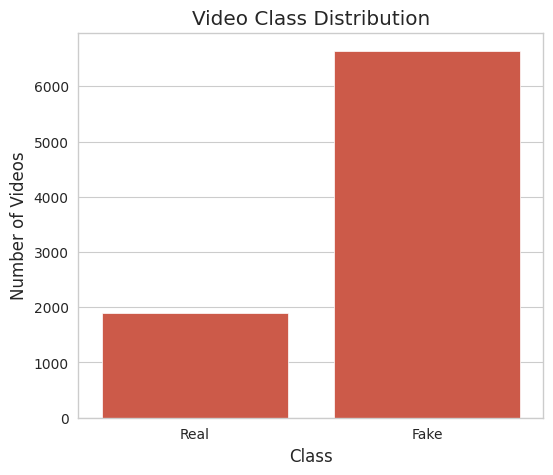

In [10]:
# ==========================================================
# 5.2 Class Distribution
# ==========================================================

video_summary = pd.DataFrame({

    "Class": ["Real", "Fake"],

    "Videos": [
        len(real_videos),
        len(fake_videos)
    ]

})

display(video_summary)

plt.figure(figsize=(6,5))

sns.barplot(
    data=video_summary,
    x="Class",
    y="Videos"
)

plt.title("Video Class Distribution")
plt.ylabel("Number of Videos")
plt.show()

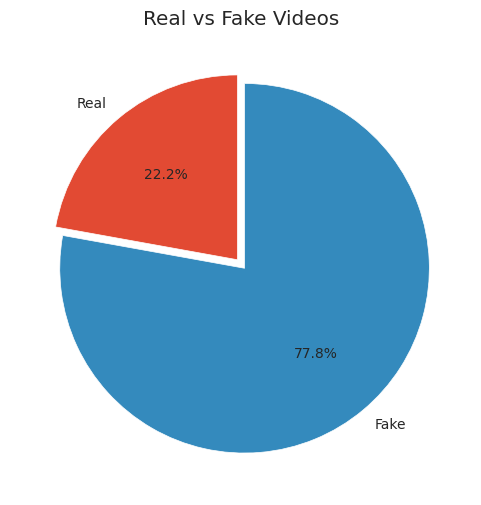

In [11]:
# ==========================================================
# 5.3 Class Distribution Pie Chart
# ==========================================================

plt.figure(figsize=(6,6))

plt.pie(
    video_summary["Videos"],
    labels=video_summary["Class"],
    autopct="%1.1f%%",
    startangle=90,
    explode=(0.03,0.03)
)

plt.title("Real vs Fake Videos")

plt.show()

In [12]:
# ==========================================================
# 5.4 Read Video Metadata
# ==========================================================

def get_video_info(video_path):

    cap = cv2.VideoCapture(str(video_path))

    fps = cap.get(cv2.CAP_PROP_FPS)

    frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))

    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    duration = frames / fps if fps > 0 else 0

    cap.release()

    return {

        "fps": fps,

        "frames": frames,

        "duration": duration,

        "width": width,

        "height": height

    }

In [13]:
# ==========================================================
# 5.5 Analyze Sample Videos
# ==========================================================

SAMPLE_SIZE = 200

sample_videos = (
    real_videos[:100] +
    fake_videos[:100]
)

video_stats = []

for video in tqdm(sample_videos):

    info = get_video_info(video)

    video_stats.append(info)

video_stats = pd.DataFrame(video_stats)

display(video_stats.head())

100%|██████████| 200/200 [00:06<00:00, 29.44it/s]


,fps,frames,duration,width,height
0,25.0,396,15.84,640,480
1,25.0,460,18.40,1280,720
2,30.0,693,23.10,1280,720
3,25.0,303,12.12,640,480
4,25.0,309,12.36,1280,720


In [14]:
# ==========================================================
# 5.6 Video Statistics
# ==========================================================

display(video_stats.describe().round(2))

,fps,frames,duration,width,height
count,200.00,200.00,200.00,200.00,200.00
mean,25.51,598.37,23.85,1435.51,843.00
std,2.48,293.98,12.42,563.63,270.99
min,15.00,33.00,1.38,586.00,480.00
25%,24.00,367.75,13.99,656.00,480.00
50%,24.00,534.00,21.04,1920.00,1080.00
75%,25.00,773.25,30.82,1920.00,1080.00
max,30.00,1466.00,61.08,1920.00,1080.00


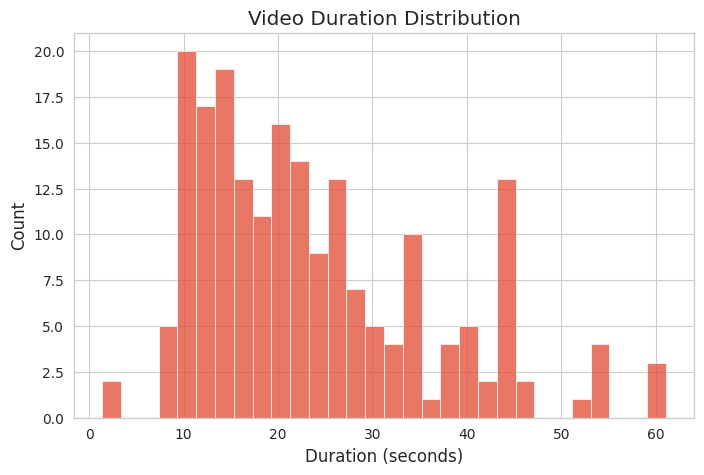

In [15]:
# ==========================================================
# 5.7 Duration Distribution
# ==========================================================

plt.figure(figsize=(8,5))

sns.histplot(
    video_stats["duration"],
    bins=30
)

plt.xlabel("Duration (seconds)")
plt.title("Video Duration Distribution")

plt.show()

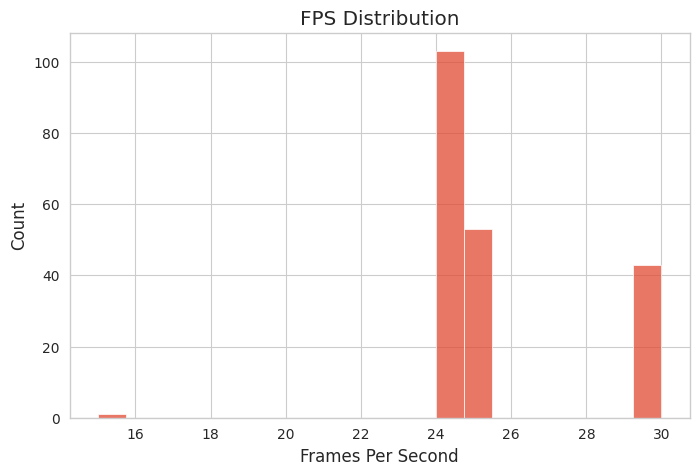

In [16]:
# ==========================================================
# 5.8 FPS Distribution
# ==========================================================

plt.figure(figsize=(8,5))

sns.histplot(
    video_stats["fps"],
    bins=20
)

plt.xlabel("Frames Per Second")

plt.title("FPS Distribution")

plt.show()

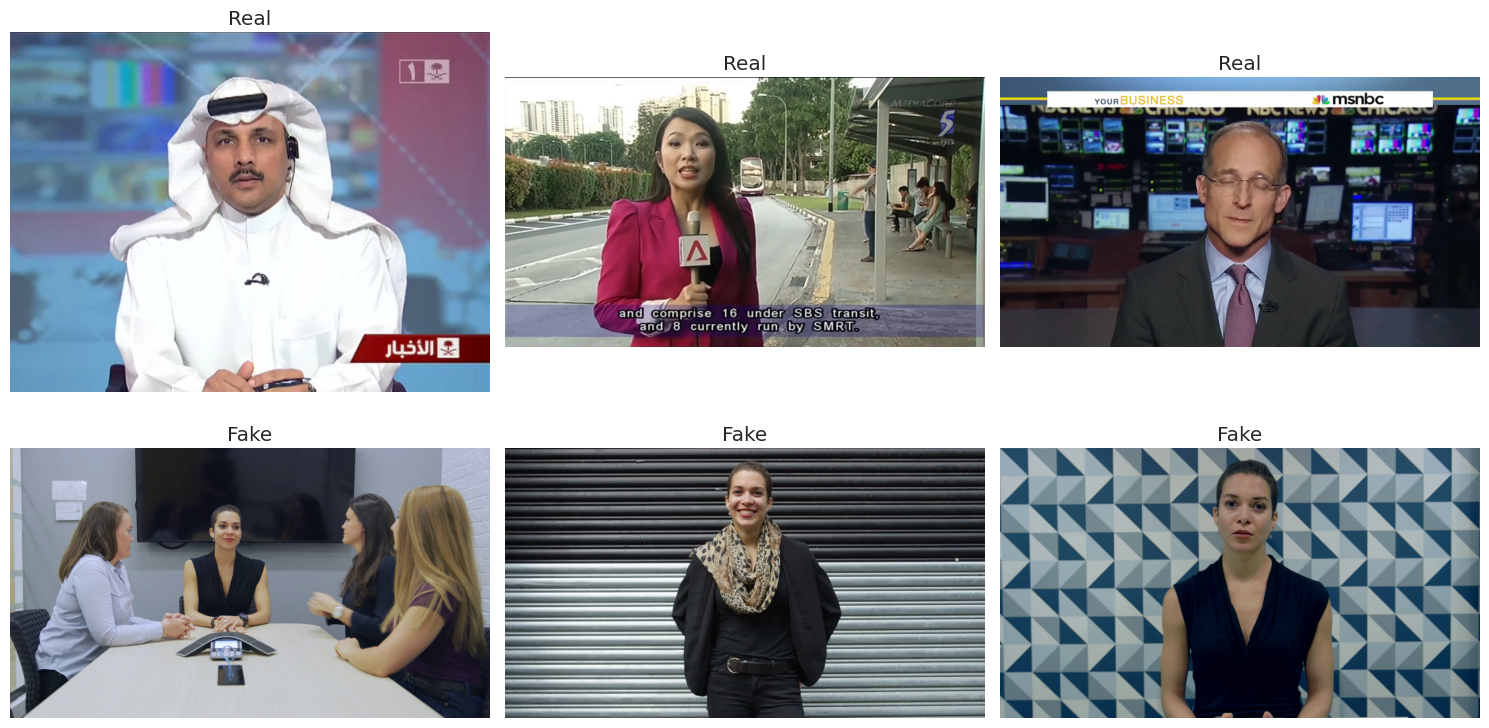

In [17]:
# ==========================================================
# 5.10 Display Sample Videos
# ==========================================================

def show_video_thumbnail(video_path):

    cap = cv2.VideoCapture(str(video_path))

    success, frame = cap.read()

    cap.release()

    if success:

        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

        return frame

    return None


sample_display = (
    real_videos[:3] +
    fake_videos[:3]
)

plt.figure(figsize=(15,8))

for i, video in enumerate(sample_display):

    image = show_video_thumbnail(video)

    plt.subplot(2,3,i+1)

    if image is not None:

        plt.imshow(image)

    plt.axis("off")

    title = "Real" if i < 3 else "Fake"

    plt.title(title)

plt.tight_layout()

plt.show()

In [18]:
# ==========================================================
# 5.11 Dataset Summary
# ==========================================================

print("="*70)

print("Total Videos :", len(real_videos)+len(fake_videos))

print("Real Videos  :", len(real_videos))

print("Fake Videos  :", len(fake_videos))

print("Average FPS  :", round(video_stats["fps"].mean(),2))

print("Average Length :", round(video_stats["duration"].mean(),2),"sec")

print("Average Frames :", int(video_stats["frames"].mean()))

print("="*70)

Total Videos : 8529
Real Videos  : 1890
Fake Videos  : 6639
Average FPS  : 25.51
Average Length : 23.85 sec
Average Frames : 598


# 6. Uniform Frame Extraction

## Objective

The original datasets (FaceForensics++ and Celeb-DF v2) contain videos rather than images.

Since EfficientNet-B2 is an image classification model, representative frames must first be extracted from each video.

Instead of extracting every frame, which creates a large amount of redundant data, this notebook uses **uniform frame sampling**.

### Workflow

Video

↓

Read Total Frames

↓

Uniform Sampling

↓

Extract N Frames

↓

Save as Images

↓

Next Video

### Advantages

- Reduces redundant frames
- Faster preprocessing
- Lower storage requirements
- Better dataset diversity
- Common practice in deepfake detection research

The extracted frames will be stored separately for the **Real** and **Fake** classes and used in the subsequent face detection stage.

In [19]:
# ==========================================================
# Recreate Working Directories (Run after Runtime Restart)
# ==========================================================

from pathlib import Path

# Base working directory
WORKING_DIR = Path("/kaggle/working")

# Frame directories
FRAME_DIR = WORKING_DIR / "Extracted_Frames"

REAL_FRAME_DIR = FRAME_DIR / "Real"
FAKE_FRAME_DIR = FRAME_DIR / "Fake"

# Face directories (for upcoming RetinaFace section)
FACE_DIR = WORKING_DIR / "Detected_Faces"

REAL_FACE_DIR = FACE_DIR / "Real"
FAKE_FACE_DIR = FACE_DIR / "Fake"

# Model directory
MODEL_DIR = WORKING_DIR / "Saved_Models"

# Results directory
RESULT_DIR = WORKING_DIR / "Results"

# Create folders if they don't exist
for folder in [
    FRAME_DIR,
    REAL_FRAME_DIR,
    FAKE_FRAME_DIR,
    FACE_DIR,
    REAL_FACE_DIR,
    FAKE_FACE_DIR,
    MODEL_DIR,
    RESULT_DIR,
]:
    folder.mkdir(parents=True, exist_ok=True)

print("=" * 60)
print("Working directories initialized successfully.")
print("=" * 60)

print("WORKING_DIR :", WORKING_DIR)
print("FRAME_DIR   :", FRAME_DIR)
print("FACE_DIR    :", FACE_DIR)
print("MODEL_DIR   :", MODEL_DIR)
print("RESULT_DIR  :", RESULT_DIR)

Working directories initialized successfully.
WORKING_DIR : /kaggle/working
FRAME_DIR   : /kaggle/working/Extracted_Frames
FACE_DIR    : /kaggle/working/Detected_Faces
MODEL_DIR   : /kaggle/working/Saved_Models
RESULT_DIR  : /kaggle/working/Results


In [20]:
# ==========================================================
# Recreate Working Directories (Run after Runtime Restart)
# ==========================================================

from pathlib import Path

# Base working directory
WORKING_DIR = Path("/kaggle/working")

# Frame directories
FRAME_DIR = WORKING_DIR / "Extracted_Frames"

REAL_FRAME_DIR = FRAME_DIR / "Real"
FAKE_FRAME_DIR = FRAME_DIR / "Fake"

# Face directories (for upcoming RetinaFace section)
FACE_DIR = WORKING_DIR / "Detected_Faces"

REAL_FACE_DIR = FACE_DIR / "Real"
FAKE_FACE_DIR = FACE_DIR / "Fake"

# Model directory
MODEL_DIR = WORKING_DIR / "Saved_Models"

# Results directory
RESULT_DIR = WORKING_DIR / "Results"

# Create folders if they don't exist
for folder in [
    FRAME_DIR,
    REAL_FRAME_DIR,
    FAKE_FRAME_DIR,
    FACE_DIR,
    REAL_FACE_DIR,
    FAKE_FACE_DIR,
    MODEL_DIR,
    RESULT_DIR,
]:
    folder.mkdir(parents=True, exist_ok=True)

print("=" * 60)
print("Working directories initialized successfully.")
print("=" * 60)

print("WORKING_DIR :", WORKING_DIR)
print("FRAME_DIR   :", FRAME_DIR)
print("FACE_DIR    :", FACE_DIR)
print("MODEL_DIR   :", MODEL_DIR)
print("RESULT_DIR  :", RESULT_DIR)

Working directories initialized successfully.
WORKING_DIR : /kaggle/working
FRAME_DIR   : /kaggle/working/Extracted_Frames
FACE_DIR    : /kaggle/working/Detected_Faces
MODEL_DIR   : /kaggle/working/Saved_Models
RESULT_DIR  : /kaggle/working/Results


In [21]:
# ==========================================================
# 6.2 Frame Extraction Parameters
# ==========================================================

FRAMES_PER_VIDEO = 5

FACE_SIZE = (224,224)

FACE_MARGIN = 0.10

print("="*70)

print("Frames per Video :", FRAMES_PER_VIDEO)

print("Output Face Size :", FACE_SIZE)

print("Bounding Box Margin :", FACE_MARGIN)

print("="*70)

Frames per Video : 5
Output Face Size : (224, 224)
Bounding Box Margin : 0.1


In [22]:
!pip install -q retina-face

In [23]:
# ==========================================================
# 6.3 RetinaFace Detection
# ==========================================================

from retinaface import RetinaFace

def extract_largest_face(image):

    try:

        detections = RetinaFace.detect_faces(image)

    except:

        return None

    if not isinstance(detections, dict):

        return None

    largest_area = 0
    best_face = None

    for face in detections.values():

        x1, y1, x2, y2 = face["facial_area"]

        area = (x2-x1)*(y2-y1)

        if area > largest_area:

            largest_area = area
            best_face = (x1,y1,x2,y2)

    if best_face is None:

        return None

    return best_face

In [24]:
# ==========================================================
# 6.4 Extract Uniform Frames
# ==========================================================

import cv2
import numpy as np

def extract_frames(video_path, output_dir):

    cap = cv2.VideoCapture(str(video_path))

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if total_frames == 0:
        cap.release()
        return 0

    frame_indices = np.linspace(
        0,
        total_frames - 1,
        FRAMES_PER_VIDEO,
        dtype=int
    )

    saved = 0

    video_name = Path(video_path).stem

    for idx in frame_indices:

        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)

        success, frame = cap.read()

        if not success:
            continue

        # Resize for EfficientNet-B2
        frame = cv2.resize(frame, IMAGE_SIZE)

        save_path = output_dir / f"{video_name}_frame_{idx}.jpg"

        cv2.imwrite(str(save_path), frame)

        saved += 1

    cap.release()

    return saved

In [25]:
# ==========================================================
# Recreate Video Lists
# ==========================================================

VIDEO_EXTENSIONS = (".mp4", ".avi", ".mov", ".mkv")


def get_video_list(folder):

    videos = []

    for file in sorted(os.listdir(folder)):

        if file.lower().endswith(VIDEO_EXTENSIONS):
            videos.append(folder / file)

    return videos


# -----------------------------
# FaceForensics++
# -----------------------------

ffpp_real_videos = get_video_list(FFPP_REAL)
ffpp_fake_videos = get_video_list(FFPP_FAKE)

# -----------------------------
# Celeb-DF
# -----------------------------

celeb_real_videos = get_video_list(CELEB_REAL)
youtube_real_videos = get_video_list(YOUTUBE_REAL)
celeb_fake_videos = get_video_list(CELEB_FAKE)

# -----------------------------
# Merge datasets
# -----------------------------

real_videos = (
    ffpp_real_videos +
    celeb_real_videos +
    youtube_real_videos
)

fake_videos = (
    ffpp_fake_videos +
    celeb_fake_videos
)

# -----------------------------
# Balance dataset
# -----------------------------

MAX_REAL_VIDEOS = 1000
MAX_FAKE_VIDEOS = 1000

random.shuffle(real_videos)
random.shuffle(fake_videos)

real_videos = real_videos[:MAX_REAL_VIDEOS]
fake_videos = fake_videos[:MAX_FAKE_VIDEOS]

print("=" * 60)
print("Video Lists Created")
print("=" * 60)
print(f"Real Videos : {len(real_videos)}")
print(f"Fake Videos : {len(fake_videos)}")
print("=" * 60)

Video Lists Created
Real Videos : 1000
Fake Videos : 1000


In [26]:
# ==========================================================
# 6.5 Extract Real Frames
# ==========================================================

from tqdm import tqdm

real_saved = 0

for video in tqdm(real_videos):

    real_saved += extract_frames(
        video,
        REAL_FRAME_DIR
    )

print("=" * 60)
print(f"Real Frames Saved : {real_saved:,}")
print("=" * 60)

100%|██████████| 1000/1000 [12:07<00:00,  1.37it/s]

Real Frames Saved : 4,996


In [27]:
# ==========================================================
# 6.6 Extract Fake Frames
# ==========================================================

fake_saved = 0

for video in tqdm(fake_videos):

    fake_saved += extract_frames(
        video,
        FAKE_FRAME_DIR
    )

print("=" * 60)
print(f"Fake Frames Saved : {fake_saved:,}")
print("=" * 60)

100%|██████████| 1000/1000 [07:47<00:00,  2.14it/s]

Fake Frames Saved : 5,000


In [28]:
# ==========================================================
# 6.7 Verify Frame Dataset
# ==========================================================

real_frames = sorted(REAL_FRAME_DIR.glob("*.jpg"))
fake_frames = sorted(FAKE_FRAME_DIR.glob("*.jpg"))

print("=" * 60)
print("Frame Dataset Summary")
print("=" * 60)

print(f"Real Frames : {len(real_frames):,}")
print(f"Fake Frames : {len(fake_frames):,}")
print(f"Total Frames: {len(real_frames) + len(fake_frames):,}")

print("=" * 60)

Frame Dataset Summary
Real Frames : 4,996
Fake Frames : 5,000
Total Frames: 9,996


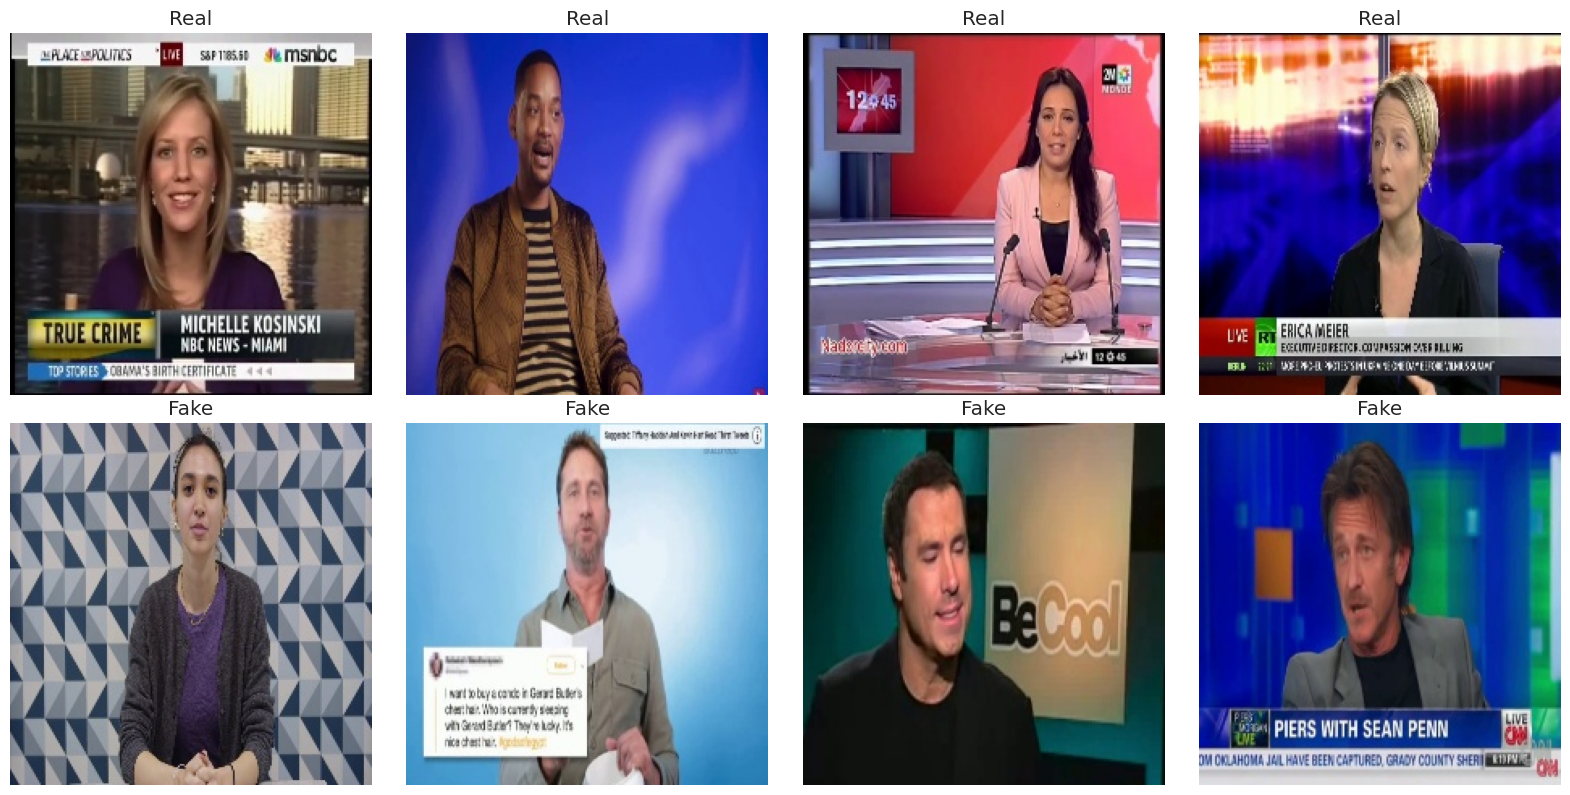

In [29]:
# ==========================================================
# 6.8 Display Sample Frames
# ==========================================================

import random
import matplotlib.pyplot as plt

sample_real = random.sample(real_frames, min(4, len(real_frames)))
sample_fake = random.sample(fake_frames, min(4, len(fake_frames)))

samples = sample_real + sample_fake

plt.figure(figsize=(16, 8))

for i, img_path in enumerate(samples):

    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(2, 4, i + 1)
    plt.imshow(img)
    plt.axis("off")
    plt.title("Real" if i < len(sample_real) else "Fake")

plt.tight_layout()
plt.show()

# 7. Exploratory Data Analysis (EDA) of Extracted Frames

## Objective

After extracting representative frames from the videos, it is important to evaluate the quality of the resulting image dataset before model training.

This section performs exploratory data analysis (EDA) on the extracted frames to verify:

- Number of extracted frames
- Class distribution
- Sample images
- Image resolution
- Pixel intensity distribution
- RGB color distribution

This helps ensure that the extracted dataset is suitable for deep learning.

In [30]:
# ==========================================================
# 7.2 Dataset Summary
# ==========================================================

frame_summary = pd.DataFrame({

    "Class":["Real","Fake"],

    "Frames":[
        len(real_frames),
        len(fake_frames)
    ]

})

display(frame_summary)

,Class,Frames
0,Real,4996
1,Fake,5000


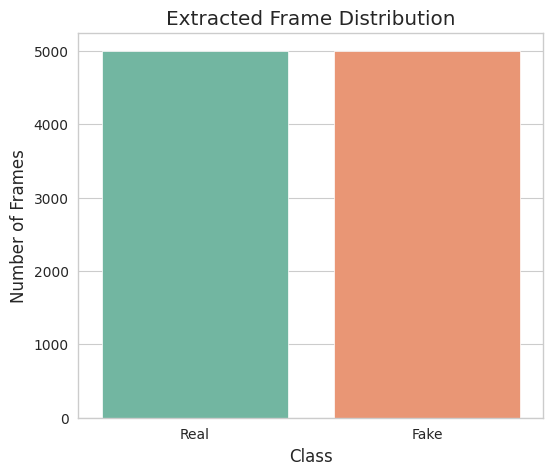

In [31]:
# ==========================================================
# 7.3 Class Distribution
# ==========================================================

plt.figure(figsize=(6,5))

sns.barplot(
    data=frame_summary,
    x="Class",
    y="Frames",
    palette="Set2"
)

plt.title("Extracted Frame Distribution")

plt.ylabel("Number of Frames")

plt.show()

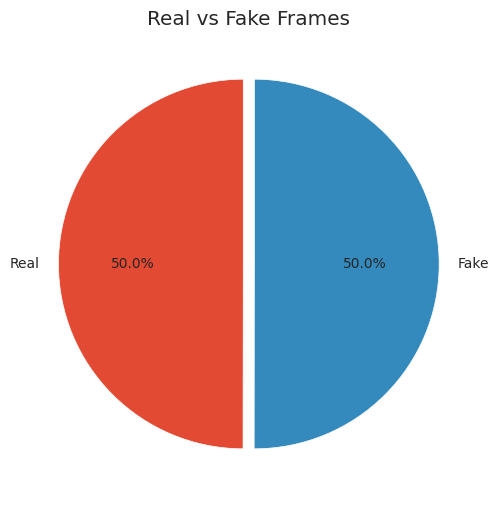

In [32]:
# ==========================================================
# 7.4 Pie Chart
# ==========================================================

plt.figure(figsize=(6,6))

plt.pie(
    frame_summary["Frames"],
    labels=frame_summary["Class"],
    autopct="%1.1f%%",
    explode=(0.03,0.03),
    startangle=90
)

plt.title("Real vs Fake Frames")

plt.show()

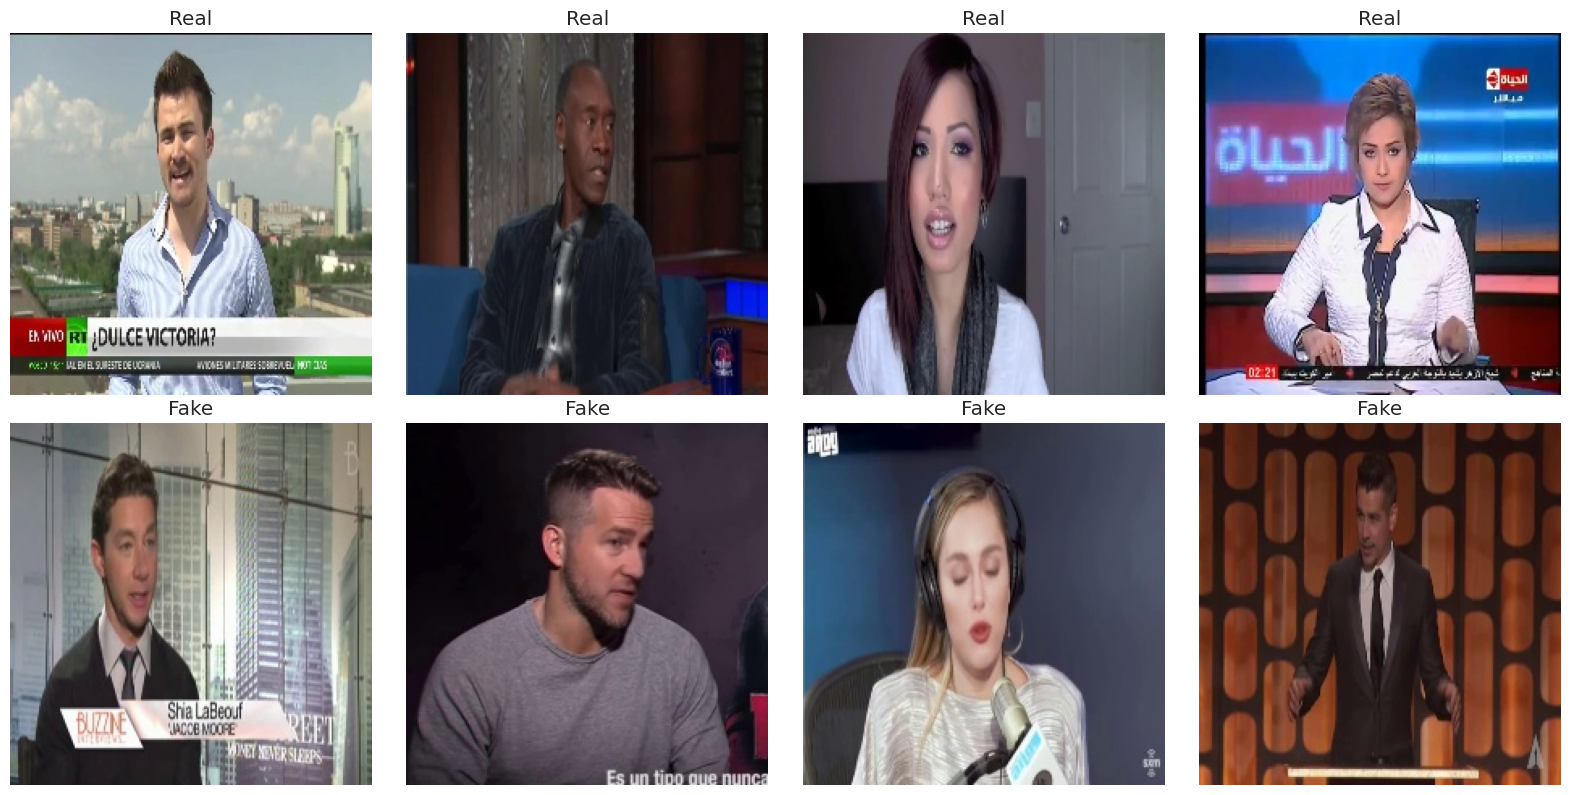

In [33]:
# ==========================================================
# 7.5 Sample Images
# ==========================================================

import random

sample_real = random.sample(
    real_frames,
    min(4,len(real_frames))
)

sample_fake = random.sample(
    fake_frames,
    min(4,len(fake_frames))
)

samples = sample_real + sample_fake

plt.figure(figsize=(16,8))

for i,img_path in enumerate(samples):

    img=cv2.imread(str(img_path))
    img=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)

    plt.subplot(2,4,i+1)

    plt.imshow(img)

    plt.axis("off")

    plt.title("Real" if i<4 else "Fake")

plt.tight_layout()

plt.show()

In [34]:
# ==========================================================
# 7.6 Image Resolution
# ==========================================================

image_sizes=[]

sample_images=random.sample(
    real_frames+fake_frames,
    min(500,len(real_frames)+len(fake_frames))
)

for img_path in sample_images:

    img=cv2.imread(str(img_path))

    h,w=img.shape[:2]

    image_sizes.append([w,h])

image_sizes=pd.DataFrame(
    image_sizes,
    columns=["Width","Height"]
)

display(image_sizes.describe())

,Width,Height
count,500.0,500.0
mean,224.0,224.0
std,0.0,0.0
min,224.0,224.0
25%,224.0,224.0
50%,224.0,224.0
75%,224.0,224.0
max,224.0,224.0


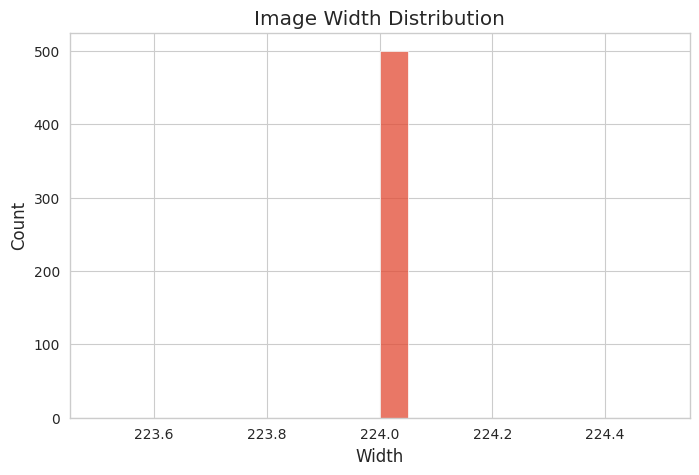

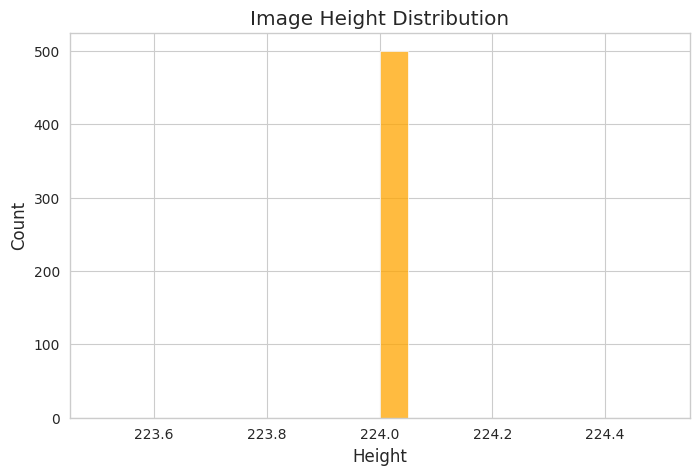

In [35]:
# ==========================================================
# 7.7 Resolution Distribution
# ==========================================================

plt.figure(figsize=(8,5))

sns.histplot(
    image_sizes["Width"],
    bins=20
)

plt.title("Image Width Distribution")

plt.show()


plt.figure(figsize=(8,5))

sns.histplot(
    image_sizes["Height"],
    bins=20,
    color="orange"
)

plt.title("Image Height Distribution")

plt.show()

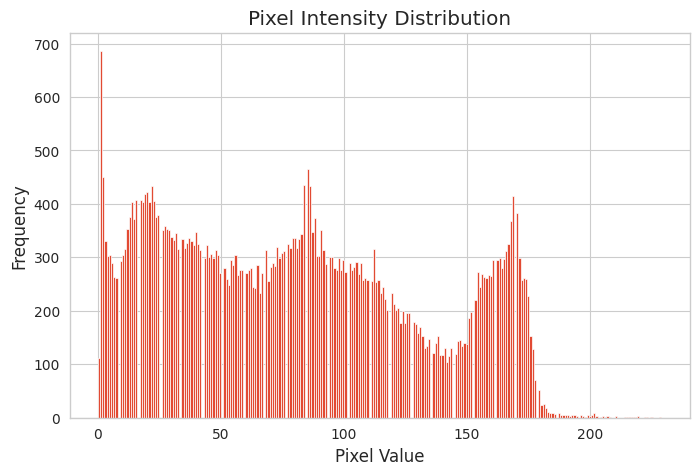

In [36]:
# ==========================================================
# 7.9 Pixel Intensity
# ==========================================================

gray=cv2.cvtColor(
    img,
    cv2.COLOR_RGB2GRAY
)

plt.figure(figsize=(8,5))

plt.hist(
    gray.ravel(),
    bins=256
)

plt.title("Pixel Intensity Distribution")

plt.xlabel("Pixel Value")

plt.ylabel("Frequency")

plt.show()

# 8. Train / Validation / Test Split

## Objective

Before training the deep learning model, the extracted frames are divided into three independent subsets:

- **Training Set (70%)**
- **Validation Set (15%)**
- **Testing Set (15%)**

The training set is used for learning the model parameters, the validation set is used for hyperparameter tuning, and the testing set is used for final performance evaluation.

This split ensures that the model is evaluated on previously unseen data, providing an unbiased estimate of its generalization performance.

In [37]:
# ==========================================================
# 8.1 Import Libraries
# ==========================================================

import os
import shutil
import random
from pathlib import Path

from sklearn.model_selection import train_test_split

In [38]:
# ==========================================================
# 8.2 Create Train / Validation / Test Directories
# ==========================================================

DATASET_DIR = WORKING_DIR / "Dataset"

TRAIN_REAL = DATASET_DIR / "train" / "Real"
TRAIN_FAKE = DATASET_DIR / "train" / "Fake"

VALID_REAL = DATASET_DIR / "validation" / "Real"
VALID_FAKE = DATASET_DIR / "validation" / "Fake"

TEST_REAL = DATASET_DIR / "test" / "Real"
TEST_FAKE = DATASET_DIR / "test" / "Fake"

folders = [
    TRAIN_REAL, TRAIN_FAKE,
    VALID_REAL, VALID_FAKE,
    TEST_REAL, TEST_FAKE
]

for folder in folders:
    folder.mkdir(parents=True, exist_ok=True)

print("Dataset folders created successfully.")

Dataset folders created successfully.


In [39]:
# ==========================================================
# 8.3 Split Real Images
# ==========================================================

train_real, temp_real = train_test_split(
    real_frames,
    test_size=0.30,
    random_state=SEED,
    shuffle=True
)

valid_real, test_real = train_test_split(
    temp_real,
    test_size=0.50,
    random_state=SEED,
    shuffle=True
)

print("Real Images")

print("Train :", len(train_real))
print("Validation :", len(valid_real))
print("Test :", len(test_real))

Real Images
Train : 3497
Validation : 749
Test : 750


In [40]:
# ==========================================================
# 8.4 Split Fake Images
# ==========================================================

train_fake, temp_fake = train_test_split(
    fake_frames,
    test_size=0.30,
    random_state=SEED,
    shuffle=True
)

valid_fake, test_fake = train_test_split(
    temp_fake,
    test_size=0.50,
    random_state=SEED,
    shuffle=True
)

print("Fake Images")

print("Train :", len(train_fake))
print("Validation :", len(valid_fake))
print("Test :", len(test_fake))

Fake Images
Train : 3500
Validation : 750
Test : 750


In [41]:
# ==========================================================
# 8.5 Copy Images
# ==========================================================

def copy_images(image_list, destination):

    for img in image_list:
        shutil.copy(img, destination)


print("Copying training images...")

copy_images(train_real, TRAIN_REAL)
copy_images(train_fake, TRAIN_FAKE)

print("Copying validation images...")

copy_images(valid_real, VALID_REAL)
copy_images(valid_fake, VALID_FAKE)

print("Copying testing images...")

copy_images(test_real, TEST_REAL)
copy_images(test_fake, TEST_FAKE)

print("Dataset split completed.")

Copying training images...
Copying validation images...
Copying testing images...
Dataset split completed.


In [42]:
# ==========================================================
# 8.6 Verify Dataset Split
# ==========================================================

summary = pd.DataFrame({

    "Dataset":[
        "Train",
        "Validation",
        "Test"
    ],

    "Real":[
        len(train_real),
        len(valid_real),
        len(test_real)
    ],

    "Fake":[
        len(train_fake),
        len(valid_fake),
        len(test_fake)
    ]

})

summary["Total"] = summary["Real"] + summary["Fake"]

display(summary)

,Dataset,Real,Fake,Total
0,Train,3497,3500,6997
1,Validation,749,750,1499
2,Test,750,750,1500


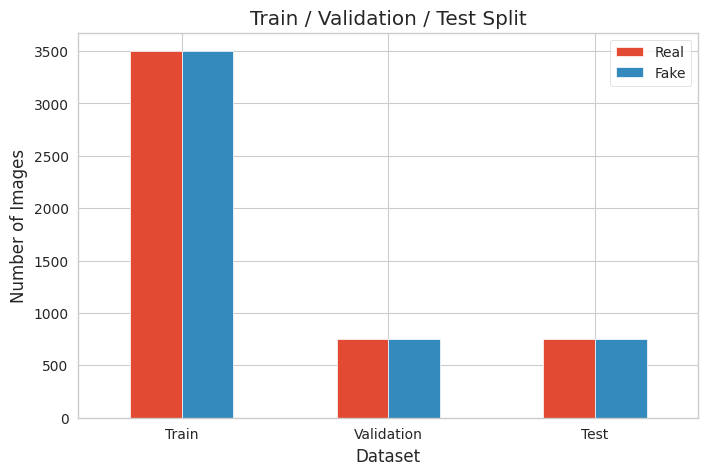

In [43]:
# ==========================================================
# 8.7 Visualize Dataset Split
# ==========================================================

summary.set_index("Dataset")[["Real", "Fake"]].plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Train / Validation / Test Split")

plt.ylabel("Number of Images")

plt.xticks(rotation=0)

plt.show()

# 9. Deepfake-Specific Data Augmentation

## Objective

Data augmentation improves the generalization capability of deep learning models by exposing them to a diverse range of image variations during training.

Unlike conventional image classification tasks, deepfake detection models must remain robust against various post-processing operations commonly encountered in real-world scenarios.

This section applies both standard image augmentations and deepfake-specific augmentations.

### Standard Augmentations

- Horizontal Flip
- Rotation
- Zoom
- Brightness Adjustment
- Width Shift
- Height Shift

### Deepfake-Specific Augmentations

- JPEG Compression
- Screenshot Simulation
- Gaussian Blur
- Gaussian Noise
- Color Jitter
- Random Erasing

Only the training dataset is augmented. Validation and testing datasets remain unchanged except for normalization.

In [44]:
# ==========================================================
# 9.1 Import Libraries
# ==========================================================

import cv2
import random
import numpy as np

from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [45]:
# ==========================================================
# 9.2 JPEG Compression
# ==========================================================

def jpeg_compression(img):

    img = (img * 255).astype(np.uint8)

    quality = random.randint(40, 95)

    _, encoded = cv2.imencode(
        ".jpg",
        img,
        [int(cv2.IMWRITE_JPEG_QUALITY), quality]
    )

    img = cv2.imdecode(encoded, cv2.IMREAD_COLOR)

    return img.astype(np.float32) / 255.0

In [46]:
# ==========================================================
# 9.3 Gaussian Blur
# ==========================================================

def gaussian_blur(img):

    if random.random() < 0.30:

        img = cv2.GaussianBlur(img, (3,3), 0)

    return img

In [47]:
# ==========================================================
# 9.4 Gaussian Noise
# ==========================================================

def gaussian_noise(img):

    if random.random() < 0.30:

        noise = np.random.normal(
            0,
            0.03,
            img.shape
        )

        img = np.clip(img + noise, 0, 1)

    return img

In [48]:
# ==========================================================
# 9.5 Screenshot Simulation
# ==========================================================

def screenshot_simulation(img):

    if random.random() < 0.30:

        h, w = img.shape[:2]

        scale = random.uniform(0.7, 0.9)

        img = cv2.resize(
            img,
            (int(w * scale), int(h * scale))
        )

        img = cv2.resize(img, (w, h))

    return img

In [49]:
# ==========================================================
# 9.8 Deepfake Preprocessing
# ==========================================================

def deepfake_preprocessing(img):

    img = img.astype(np.float32)

    if img.max() > 1:
        img /= 255.0

    img = jpeg_compression(img)
    img = screenshot_simulation(img)
    img = gaussian_blur(img)
    img = gaussian_noise(img)

    return img

In [50]:
import tensorflow as tf

AUTOTUNE = tf.data.AUTOTUNE

In [52]:
# ==========================================================
# Fix Dataset Directory Variables
# ==========================================================

from pathlib import Path

DATASET_DIR = WORKING_DIR / "Dataset"

TRAIN_DIR = DATASET_DIR / "train"
VALID_DIR = DATASET_DIR / "validation"
TEST_DIR = DATASET_DIR / "test"

print("TRAIN_DIR :", TRAIN_DIR)
print("VALID_DIR :", VALID_DIR)
print("TEST_DIR  :", TEST_DIR)

TRAIN_DIR : /kaggle/working/Dataset/train
VALID_DIR : /kaggle/working/Dataset/validation
TEST_DIR  : /kaggle/working/Dataset/test


In [53]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels="inferred",
    label_mode="binary",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

validation_dataset = tf.keras.utils.image_dataset_from_directory(
    VALID_DIR,
    labels="inferred",
    label_mode="binary",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    labels="inferred",
    label_mode="binary",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 6997 files belonging to 2 classes.
Found 1499 files belonging to 2 classes.


2026-07-13 10:15:19.421681: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Found 1500 files belonging to 2 classes.


## GPU-Optimized Data Pipeline

Replaced the legacy **ImageDataGenerator** with TensorFlow's **`tf.data` pipeline** for efficient data loading and preprocessing. The new pipeline uses `image_dataset_from_directory()`, parallel data loading (`AUTOTUNE`), caching, and prefetching to improve GPU utilization, reduce CPU bottlenecks, and provide faster, more scalable training for large datasets.

In [54]:
data_augmentation = tf.keras.Sequential([

    tf.keras.layers.RandomFlip("horizontal"),

    tf.keras.layers.RandomRotation(0.1),

    tf.keras.layers.RandomZoom(0.2),

    tf.keras.layers.RandomTranslation(
        0.2,
        0.2
    ),

    tf.keras.layers.RandomContrast(0.2),

])

def preprocess(image, label):

    image = tf.cast(image, tf.float32) / 255.0

    return image, label

train_dataset = train_dataset.map(
    preprocess,
    num_parallel_calls=AUTOTUNE
)

validation_dataset = validation_dataset.map(
    preprocess,
    num_parallel_calls=AUTOTUNE
)

test_dataset = test_dataset.map(
    preprocess,
    num_parallel_calls=AUTOTUNE
)

train_dataset = train_dataset.map(

    lambda x, y: (
        data_augmentation(x, training=True),
        y
    ),

    num_parallel_calls=AUTOTUNE

)

train_dataset = train_dataset.cache()

train_dataset = train_dataset.prefetch(AUTOTUNE)

validation_dataset = validation_dataset.cache()

validation_dataset = validation_dataset.prefetch(AUTOTUNE)

test_dataset = test_dataset.prefetch(AUTOTUNE)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0607696].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0651592].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.057002485..1.0093026].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0557468].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0125684].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0374452].


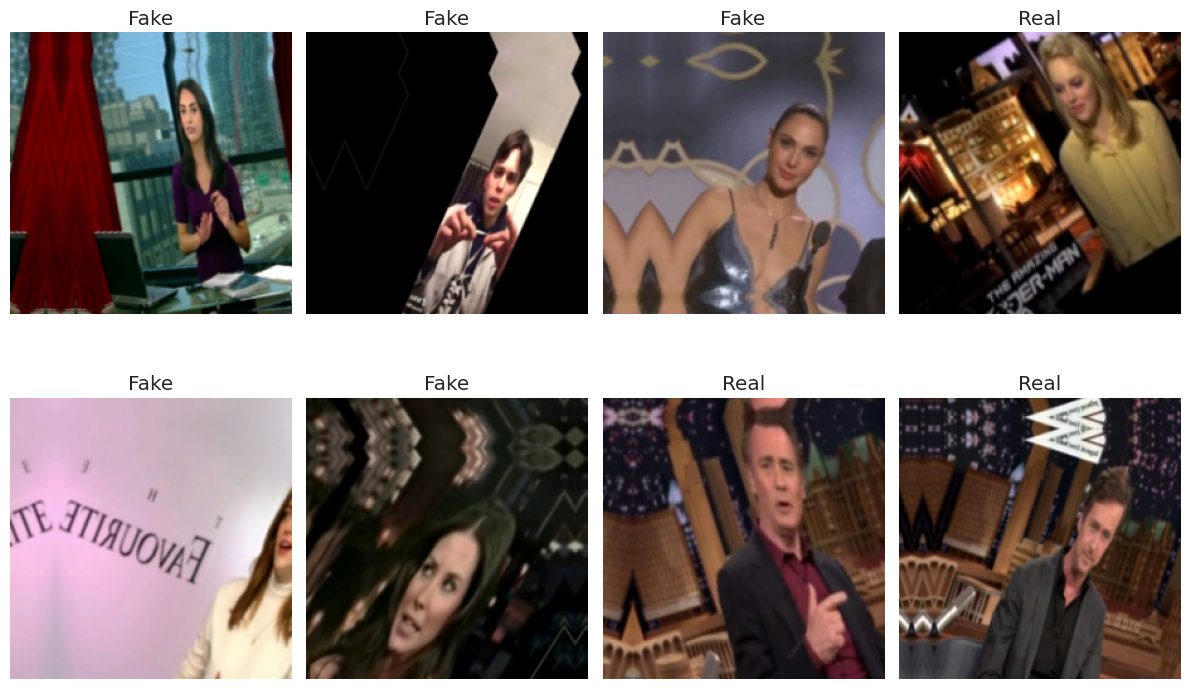

In [55]:
# ==========================================================
# 9.12 Preview Images from tf.data Pipeline
# ==========================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

for images, labels in train_dataset.take(1):

    for i in range(8):

        plt.subplot(2,4,i+1)

        plt.imshow(images[i].numpy())

        plt.title("Real" if labels[i] == 0 else "Fake")

        plt.axis("off")

plt.tight_layout()

plt.show()

# Phase 1: Verify the GPU-Optimized Data Pipeline

## Objective
Before training the model, it is important to verify that the new `tf.data` pipeline is functioning correctly. This phase ensures that the datasets are loaded successfully, preprocessing and augmentation are applied correctly, and the data is ready for EfficientNetB2 training.

## Tasks Performed
- Verified the training, validation, and test datasets.
- Displayed the number of batches in each dataset.
- Visualized a sample batch of augmented training images.
- Confirmed that images are correctly normalized and resized.
- Ensured that labels are correctly assigned for binary classification.

> This verification step helps identify preprocessing or labeling issues before model training, ensuring a reliable and efficient deep learning pipeline.

In [56]:
# ==========================================================
# Phase 1.1 Verify Dataset Information
# ==========================================================

print("=" * 60)
print("Dataset Verification")
print("=" * 60)

print(f"Training Batches   : {tf.data.experimental.cardinality(train_dataset).numpy()}")
print(f"Validation Batches : {tf.data.experimental.cardinality(validation_dataset).numpy()}")
print(f"Testing Batches    : {tf.data.experimental.cardinality(test_dataset).numpy()}")

print("=" * 60)

Dataset Verification
Training Batches   : 219
Validation Batches : 47
Testing Batches    : 47


In [57]:
# ==========================================================
# Phase 2.1 Import Libraries
# ==========================================================

from tensorflow.keras.applications import EfficientNetB2
from tensorflow.keras.layers import (
    Input,
    GlobalAveragePooling2D,
    Dense,
    Dropout,
    BatchNormalization
)
from tensorflow.keras.models import Model

In [58]:
# ==========================================================
# Phase 2.2 Load EfficientNetB2
# ==========================================================

base_model = EfficientNetB2(

    include_top=False,

    weights="imagenet",

    input_shape=(224, 224, 3)

)

# Freeze the pretrained backbone
base_model.trainable = False

31790344/31790344 [==============================] - 1s 0us/step


In [59]:
# ==========================================================
# Phase 2.3 Build Classification Head
# ==========================================================

inputs = Input(shape=(224,224,3))

x = base_model(inputs, training=False)

x = GlobalAveragePooling2D()(x)

x = BatchNormalization()(x)

x = Dropout(0.30)(x)

outputs = Dense(

    1,

    activation="sigmoid",

    name="Prediction"

)(x)

model = Model(inputs, outputs)

model.summary()

# ==========================================================
# Phase 2.5 Trainable Parameters
# ==========================================================

print("="*60)

print("Trainable Variables :", len(model.trainable_variables))

print("Non-Trainable Variables :", len(model.non_trainable_variables))

print("="*60)

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 efficientnetb2 (Functional  (None, 7, 7, 1408)        7768569   
 )                                                               
                                                                 
 global_average_pooling2d (  (None, 1408)              0         
 GlobalAveragePooling2D)                                         
                                                                 
 batch_normalization (Batch  (None, 1408)              5632      
 Normalization)                                                  
                                                                 
 dropout (Dropout)           (None, 1408)              0         
                                                             

In [60]:
# ==========================================================
# Phase 2.5 Trainable Parameters
# ==========================================================

print("="*60)

print("Trainable Variables :", len(model.trainable_variables))

print("Non-Trainable Variables :", len(model.non_trainable_variables))

print("="*60)

Trainable Variables : 4
Non-Trainable Variables : 442


In [61]:
# ==========================================================
# Phase 3.1 Import Libraries
# ==========================================================

from tensorflow.keras.optimizers import Adam

from tensorflow.keras.callbacks import (
    ModelCheckpoint,
    EarlyStopping,
    ReduceLROnPlateau
)

from tensorflow.keras.metrics import (
    BinaryAccuracy,
    Precision,
    Recall,
    AUC
)

# ==========================================================
# Phase 3.2 Compile Model
# ==========================================================

INITIAL_LR = 1e-3

model.compile(

    optimizer=Adam(learning_rate=INITIAL_LR),

    loss="binary_crossentropy",

    metrics=[
        BinaryAccuracy(name="accuracy"),
        Precision(name="precision"),
        Recall(name="recall"),
        AUC(name="auc")
    ]
)

print("Model Compiled Successfully!")

# ==========================================================
# Phase 3.3 Training Callbacks
# ==========================================================

BEST_MODEL_PATH = "EfficientNetB2_Best.keras"

checkpoint = ModelCheckpoint(

    filepath=BEST_MODEL_PATH,

    monitor="val_accuracy",

    save_best_only=True,

    mode="max",

    verbose=1

)

early_stopping = EarlyStopping(

    monitor="val_loss",

    patience=5,

    restore_best_weights=True,

    verbose=1

)

reduce_lr = ReduceLROnPlateau(

    monitor="val_loss",

    factor=0.2,

    patience=3,

    min_lr=1e-6,

    verbose=1

)

callbacks = [

    checkpoint,

    early_stopping,

    reduce_lr

]

Model Compiled Successfully!


In [62]:
# ==========================================================
# Phase 3.4 Training Configuration
# ==========================================================

print("=" * 60)
print("Training Configuration")
print("=" * 60)
print(f"Learning Rate : {INITIAL_LR}")
print(f"Loss Function : Binary Crossentropy")
print(f"Optimizer     : Adam")
print(f"Callbacks     : {len(callbacks)}")
print("=" * 60)

Training Configuration
Learning Rate : 0.001
Loss Function : Binary Crossentropy
Optimizer     : Adam
Callbacks     : 3


In [63]:
# ==========================================================
# Phase 3.4 Training Configuration
# ==========================================================

print("=" * 60)
print("Training Configuration")
print("=" * 60)
print(f"Learning Rate : {INITIAL_LR}")
print(f"Loss Function : Binary Crossentropy")
print(f"Optimizer     : Adam")
print(f"Callbacks     : {len(callbacks)}")
print("=" * 60)

Training Configuration
Learning Rate : 0.001
Loss Function : Binary Crossentropy
Optimizer     : Adam
Callbacks     : 3


In [64]:
# ==========================================================
# Phase 4.2 Compute Class Weights
# ==========================================================

import numpy as np
from sklearn.utils.class_weight import compute_class_weight

train_labels = np.concatenate([
    y.numpy().flatten()
    for _, y in train_dataset
])

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_labels),
    y=train_labels
)

class_weight_dict = {
    0: class_weights[0],
    1: class_weights[1]
}

print("Class Weights")
print(class_weight_dict)

Class Weights
{0: np.float64(0.9995714285714286), 1: np.float64(1.0004289390906491)}


In [65]:

history = model.fit(

    train_dataset,

    validation_data=validation_dataset,

    epochs=3,

    callbacks=callbacks,

    class_weight=class_weight_dict,

    verbose=1

)

Epoch 1/3
219/219 [==============================] - ETA: 0s - loss: 0.6608 - accuracy: 0.6168 - precision: 0.6411 - recall: 0.5302 - auc: 0.6545
Epoch 1: val_accuracy improved from -inf to 0.49967, saving model to EfficientNetB2_Best.keras
219/219 [==============================] - 458s 2s/step - loss: 0.6608 - accuracy: 0.6168 - precision: 0.6411 - recall: 0.5302 - auc: 0.6545 - val_loss: 0.6847 - val_accuracy: 0.4997 - val_precision: 0.4997 - val_recall: 1.0000 - val_auc: 0.6584 - lr: 0.0010
Epoch 2/3
219/219 [==============================] - ETA: 0s - loss: 0.6551 - accuracy: 0.6204 - precision: 0.6448 - recall: 0.5356 - auc: 0.6606
Epoch 2: val_accuracy improved from 0.49967 to 0.60707, saving model to EfficientNetB2_Best.keras
219/219 [==============================] - 469s 2s/step - loss: 0.6551 - accuracy: 0.6204 - precision: 0.6448 - recall: 0.5356 - auc: 0.6606 - val_loss: 0.6664 - val_accuracy: 0.6071 - val_precision: 0.5806 - val_recall: 0.7690 - val_auc: 0.6647 - lr: 0.00

In [66]:
# ==========================================================
# Phase 4.4 Save Stage 1 Model
# ==========================================================

STAGE1_MODEL_PATH = "EfficientNetB2_Stage1.keras"

model.save(STAGE1_MODEL_PATH)

print("Stage 1 Model Saved Successfully!")

Stage 1 Model Saved Successfully!


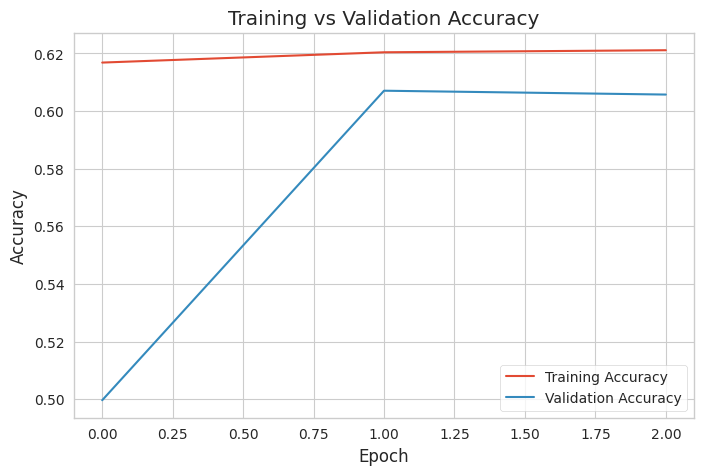

In [67]:
# ==========================================================
# Phase 4.5 Training Curves
# ==========================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")

plt.legend()

plt.show()

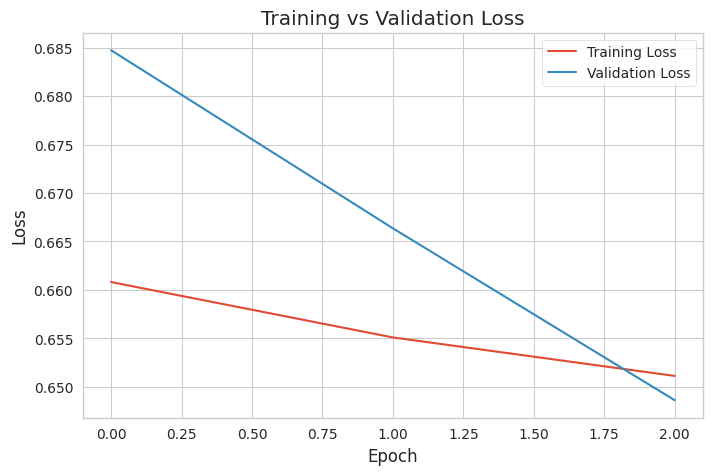

In [68]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()

plt.show()

In [69]:
# ==========================================================
# 5.1 Load Best Model
# ==========================================================

from tensorflow.keras.models import load_model

model = load_model(BEST_MODEL_PATH)

print("Best Stage 1 Model Loaded Successfully!")

Best Stage 1 Model Loaded Successfully!


In [70]:
# ==========================================================
# 5.2 Unfreeze Backbone
# ==========================================================

# Get EfficientNet backbone
base_model = model.layers[1]

base_model.trainable = True

# Freeze all except last 40 layers
for layer in base_model.layers[:-40]:
    layer.trainable = False

print("="*60)
print("Fine-Tuning Configuration")
print("="*60)
print("Trainable Layers:")

count = 0

for layer in base_model.layers:
    if layer.trainable:
        count += 1

print(count)

print("="*60)

Fine-Tuning Configuration
Trainable Layers:
40


In [71]:
# ==========================================================
# 5.3 Recompile Model
# ==========================================================

from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import BinaryAccuracy, Precision, Recall, AUC

FINE_TUNE_LR = 1e-5

model.compile(

    optimizer=Adam(FINE_TUNE_LR),

    loss="binary_crossentropy",

    metrics=[
        BinaryAccuracy(name="accuracy"),
        Precision(name="precision"),
        Recall(name="recall"),
        AUC(name="auc")
    ]

)

print("Model Recompiled!")

Model Recompiled!


In [72]:
for images, labels in train_dataset.take(1):
    print(images.shape)
    print(labels.shape)

(32, 224, 224, 3)
(32, 1)


In [73]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels="inferred",
    label_mode="binary",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=42
)

Found 6997 files belonging to 2 classes.


In [74]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import BinaryAccuracy, Precision, Recall, AUC

# Lower learning rate for fine-tuning
FINE_TUNE_LR = 1e-5

# Recompile the model with a NEW optimizer
model.compile(
    optimizer=Adam(learning_rate=FINE_TUNE_LR),
    loss="binary_crossentropy",
    metrics=[
        BinaryAccuracy(name="accuracy"),
        Precision(name="precision"),
        Recall(name="recall"),
        AUC(name="auc")
    ]
)

print("Model recompiled successfully for fine-tuning.")

Model recompiled successfully for fine-tuning.


In [75]:
model = load_model(BEST_MODEL_PATH)
base_model = model.layers[1]
base_model.trainable = True

In [76]:
# ==========================================================
# 5.4 Fine-Tune Model
# ==========================================================

FINE_TUNE_EPOCHS = 10

print("=" * 60)
print("Starting Fine-Tuning...")
print("=" * 60)

history_fine = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=FINE_TUNE_EPOCHS,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)

print("=" * 60)
print("Fine-Tuning Completed Successfully!")
print("=" * 60)

Starting Fine-Tuning...
Epoch 1/10
219/219 [==============================] - ETA: 0s - loss: 0.6101 - accuracy: 0.7199 - precision: 0.7242 - recall: 0.7098 - auc: 0.7902
Epoch 1: val_accuracy did not improve from 0.60707
219/219 [==============================] - 470s 2s/step - loss: 0.6101 - accuracy: 0.7199 - precision: 0.7242 - recall: 0.7098 - auc: 0.7902 - val_loss: 0.8179 - val_accuracy: 0.4997 - val_precision: 0.4997 - val_recall: 1.0000 - val_auc: 0.6605 - lr: 0.0010
Epoch 2/10
219/219 [==============================] - ETA: 0s - loss: 0.4893 - accuracy: 0.7723 - precision: 0.7878 - recall: 0.7452 - auc: 0.8483
Epoch 2: val_accuracy did not improve from 0.60707
219/219 [==============================] - 455s 2s/step - loss: 0.4893 - accuracy: 0.7723 - precision: 0.7878 - recall: 0.7452 - auc: 0.8483 - val_loss: 0.7349 - val_accuracy: 0.4997 - val_precision: 0.4997 - val_recall: 1.0000 - val_auc: 0.6561 - lr: 0.0010
Epoch 3/10
219/219 [==============================] - ETA: 0s 

In [77]:
# ==========================================================
# 5.5 Save Final Model
# ==========================================================

FINAL_MODEL_PATH = "EfficientNetB2_Final.keras"

model.save(FINAL_MODEL_PATH)

print("Final Model Saved Successfully!")

Final Model Saved Successfully!


In [78]:
print(history.history.keys())

dict_keys(['loss', 'accuracy', 'precision', 'recall', 'auc', 'val_loss', 'val_accuracy', 'val_precision', 'val_recall', 'val_auc', 'lr'])


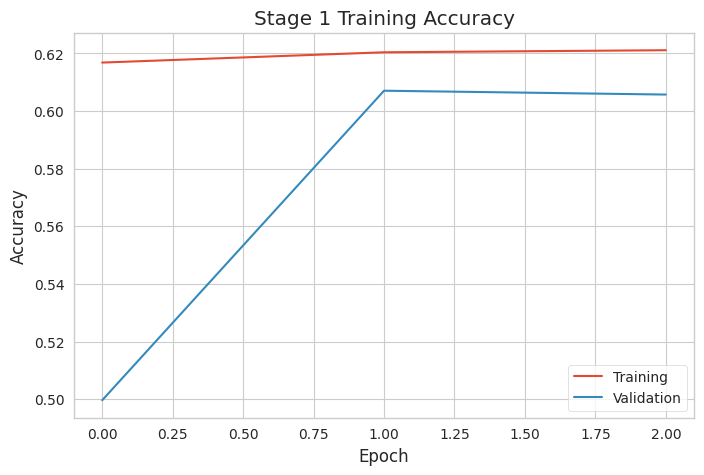

In [79]:
plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"], label="Training")
plt.plot(history.history["val_accuracy"], label="Validation")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Stage 1 Training Accuracy")

plt.legend()

plt.show()

In [80]:
print(model.input_shape)
print(model.output_shape)

model.summary()

print(train_dataset.element_spec)
print(validation_dataset.element_spec)

(None, 224, 224, 3)
(None, 1)
Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 efficientnetb2 (Functional  (None, 7, 7, 1408)        7768569   
 )                                                               
                                                                 
 global_average_pooling2d (  (None, 1408)              0         
 GlobalAveragePooling2D)                                         
                                                                 
 batch_normalization (Batch  (None, 1408)              5632      
 Normalization)                                                  
                                                                 
 dropout (Dropout)           (None, 1408)              0         
                               

# Phase 6: Model Evaluation

## Objective

After fine-tuning the EfficientNetB2 model, its performance is evaluated on the unseen test dataset. Multiple evaluation metrics are computed to assess the model's classification capability and generalization performance.

## Evaluation Metrics

The following metrics are used:

- Test Loss
- Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC Score
- Confusion Matrix
- Classification Report

These metrics provide a comprehensive assessment of the model's ability to distinguish between real and AI-generated images.

In [81]:
# ==========================================================
# 6.1 Load Final Model
# ==========================================================

from tensorflow.keras.models import load_model

model = load_model(FINAL_MODEL_PATH)

print("Final Model Loaded Successfully!")

Final Model Loaded Successfully!


In [82]:
# ==========================================================
# 6.2 Evaluate Model
# ==========================================================

results = model.evaluate(test_dataset, verbose=1)

print("="*60)

print(f"Test Loss      : {results[0]:.4f}")
print(f"Test Accuracy  : {results[1]:.4f}")
print(f"Test Precision : {results[2]:.4f}")
print(f"Test Recall    : {results[3]:.4f}")
print(f"Test AUC       : {results[4]:.4f}")

print("="*60)

47/47 [==============================] - 83s 2s/step - loss: 0.6845 - accuracy: 0.5833 - precision: 0.6855 - recall: 0.3080 - auc: 0.6317
Test Loss      : 0.6845
Test Accuracy  : 0.5833
Test Precision : 0.6855
Test Recall    : 0.3080
Test AUC       : 0.6317


In [83]:
# ==========================================================
# 6.3 Predict on Test Dataset
# ==========================================================

import numpy as np

y_true = []
y_pred_prob = []

for images, labels in test_dataset:

    predictions = model.predict(images, verbose=0)

    y_true.extend(labels.numpy().flatten())

    y_pred_prob.extend(predictions.flatten())

y_true = np.array(y_true)

y_pred_prob = np.array(y_pred_prob)

y_pred = (y_pred_prob >= 0.5).astype(int)

In [84]:
# ==========================================================
# 6.4 Classification Report
# ==========================================================

from sklearn.metrics import classification_report

print(classification_report(

    y_true,

    y_pred,

    target_names=["Real","Fake"]

))

              precision    recall  f1-score   support

        Real       0.55      0.86      0.67       750
        Fake       0.69      0.31      0.43       750

    accuracy                           0.58      1500
   macro avg       0.62      0.58      0.55      1500
weighted avg       0.62      0.58      0.55      1500



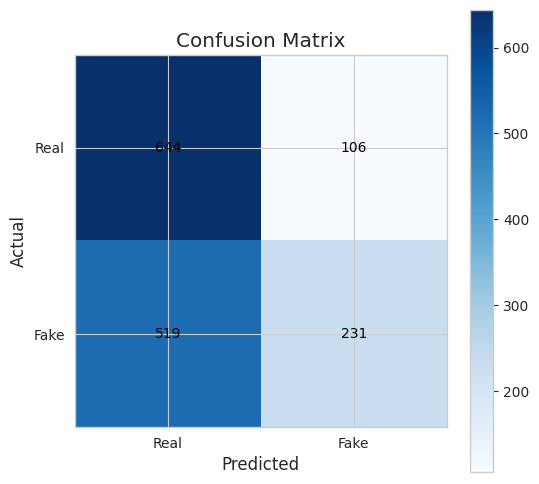

In [85]:
# ==========================================================
# 6.5 Confusion Matrix
# ==========================================================

from sklearn.metrics import confusion_matrix

import matplotlib.pyplot as plt

import numpy as np

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,6))

plt.imshow(cm, cmap="Blues")

plt.title("Confusion Matrix")

plt.colorbar()

classes = ["Real","Fake"]

ticks = np.arange(len(classes))

plt.xticks(ticks, classes)

plt.yticks(ticks, classes)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j,
            i,
            cm[i,j],
            ha="center",
            va="center",
            color="black"
        )

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [86]:
# ==========================================================
# 6.6 F1 Score
# ==========================================================

from sklearn.metrics import f1_score

f1 = f1_score(y_true, y_pred)

print(f"F1 Score : {f1:.4f}")

F1 Score : 0.4250


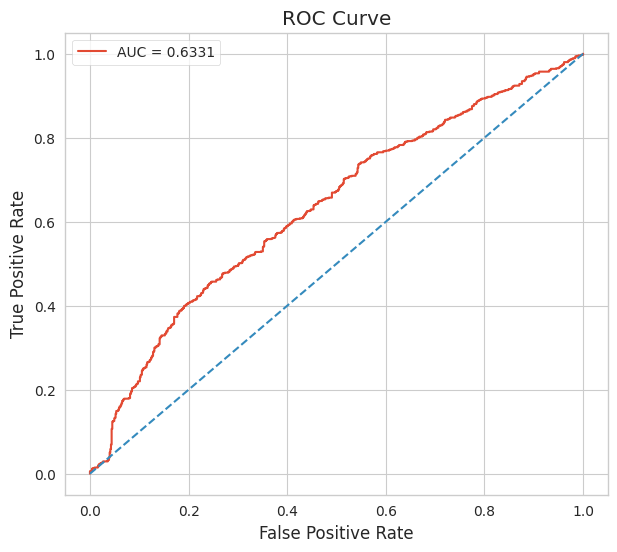

In [87]:
# ==========================================================
# 6.7 ROC Curve
# ==========================================================

from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_true, y_pred_prob)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,6))

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")

plt.plot([0,1],[0,1],"--")

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

In [88]:
# ==========================================================
# 6.8 Final Results
# ==========================================================

print("="*60)

print("FINAL MODEL PERFORMANCE")

print("="*60)

print(f"Accuracy  : {results[1]:.4f}")
print(f"Precision : {results[2]:.4f}")
print(f"Recall    : {results[3]:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"ROC AUC   : {roc_auc:.4f}")

print("="*60)

FINAL MODEL PERFORMANCE
Accuracy  : 0.5833
Precision : 0.6855
Recall    : 0.3080
F1 Score  : 0.4250
ROC AUC   : 0.6331


# Phase 7: Model Explainability using Grad-CAM

## Objective

To improve the interpretability of the deepfake detection model, **Gradient-weighted Class Activation Mapping (Grad-CAM)** is employed. Grad-CAM generates visual heatmaps that highlight the image regions most influential in the model's decision-making process.

These visualizations help verify whether the model focuses on meaningful facial features instead of irrelevant background information, thereby increasing confidence in the model's predictions.

## Key Objectives

- Generate Grad-CAM heatmaps for the trained EfficientNetB2 model.
- Visualize the regions influencing the prediction.
- Interpret the model's decision-making process.
- Compare heatmaps for real and AI-generated images.

In [89]:
# ==========================================================
# 7.1 Import Libraries
# ==========================================================

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2

In [90]:
# ==========================================================
# 7.2 Load Final Model
# ==========================================================

from tensorflow.keras.models import load_model

model = load_model(FINAL_MODEL_PATH)

print("Grad-CAM Model Loaded Successfully!")

Grad-CAM Model Loaded Successfully!


In [108]:
# ==========================================================
# 7.3 Find Last Convolution Layer
# ==========================================================

backbone = model.get_layer("efficientnetb2")

last_conv_layer = backbone.get_layer("top_conv")

print("Backbone :", backbone.name)

print("Last Conv Layer :", last_conv_layer.name)

Backbone : efficientnetb2
Last Conv Layer : top_conv


In [112]:
# ==========================================================
# 7.4 Generate Grad-CAM
# ==========================================================

import tensorflow as tf
import numpy as np

def make_gradcam_heatmap(img_array, model):

    backbone = model.get_layer("efficientnetb2")

    # Build a model that returns BOTH:
    # 1. top_conv feature maps
    # 2. EfficientNet output

    grad_model = tf.keras.Model(
        inputs=backbone.input,
        outputs=[
            backbone.get_layer("top_conv").output,
            backbone.output
        ]
    )

    # Classifier Head
    classifier_input = tf.keras.Input(shape=backbone.output.shape[1:])

    x = classifier_input

    for layer in model.layers[2:]:
        x = layer(x)

    classifier_model = tf.keras.Model(classifier_input, x)

    with tf.GradientTape() as tape:

        conv_outputs, features = grad_model(img_array)

        tape.watch(conv_outputs)

        predictions = classifier_model(features)

        loss = predictions[:,0]

    grads = tape.gradient(loss, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

    conv_outputs = conv_outputs[0]

    heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)

    heatmap = tf.maximum(heatmap,0)

    heatmap = heatmap / (tf.reduce_max(heatmap)+1e-8)

    return heatmap.numpy()

In [114]:
# ==========================================================
# 7.5 Load Sample Image
# ==========================================================

for images, labels in test_dataset.take(1):

    sample_image = images[0]

    sample_label = labels[0]

    break

img_array = tf.expand_dims(sample_image, axis=0)

In [116]:
heatmap = make_gradcam_heatmap(
    img_array,
    model,
)

In [117]:
# ==========================================================
# 7.7 Overlay Heatmap
# ==========================================================

heatmap = cv2.resize(

    heatmap,

    (224,224)

)

heatmap = np.uint8(255*heatmap)

heatmap = cv2.applyColorMap(

    heatmap,

    cv2.COLORMAP_JET

)

original = (sample_image.numpy()*255).astype(np.uint8)

overlay = cv2.addWeighted(

    original,

    0.6,

    heatmap,

    0.4,

    0

)

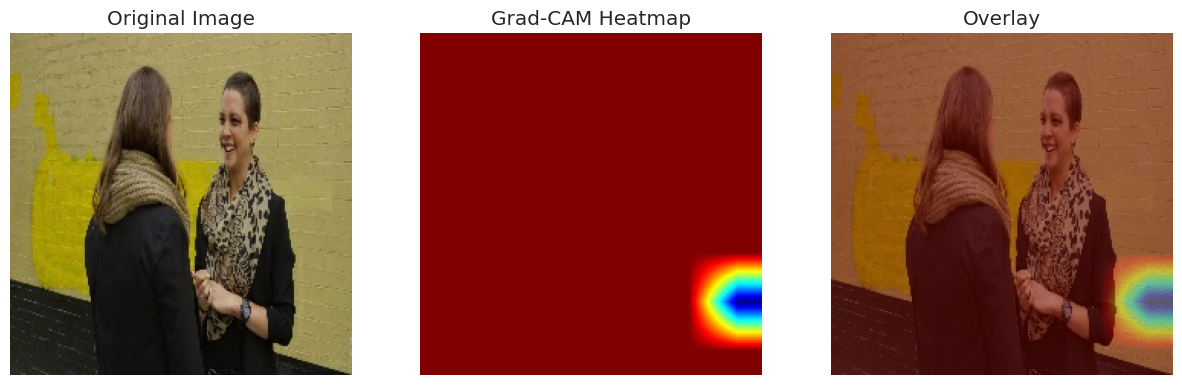

In [118]:
# ==========================================================
# 7.8 Display Grad-CAM
# ==========================================================

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)

plt.imshow(original)

plt.title("Original Image")

plt.axis("off")

plt.subplot(1,3,2)

plt.imshow(heatmap)

plt.title("Grad-CAM Heatmap")

plt.axis("off")

plt.subplot(1,3,3)

plt.imshow(overlay)

plt.title("Overlay")

plt.axis("off")

plt.show()

In [105]:
# ==========================================================
# 7.9 Prediction
# ==========================================================

prediction = model.predict(img_array)

print("="*50)

print(f"Prediction Score : {prediction[0][0]:.4f}")

if prediction >= 0.5:
    print("Predicted Class : Fake")
else:
    print("Predicted Class : Real")

print("="*50)

1/1 [==============================] - 3s 3s/step
Prediction Score : 0.4729
Predicted Class : Real


# Phase 9: Predict on Custom Images

## Objective

This phase allows the trained EfficientNetB2 model to perform inference on unseen images uploaded by the user. The uploaded image undergoes the same preprocessing pipeline used during training before being classified as **Real** or **Fake**.

The model outputs:

- Predicted Class
- Prediction Confidence
- Probability of being Real
- Probability of being Fake

This demonstrates the model's real-world applicability on previously unseen images.

In [106]:
from tensorflow.keras.models import load_model

model = load_model("EfficientNetB2_Final.keras")

print("Model Loaded Successfully!")

Model Loaded Successfully!


In [127]:
from IPython.display import display
import ipywidgets as widgets

uploader = widgets.FileUpload(
    accept='image/*',
    multiple=False
)

display(uploader)

FileUpload(value=(), accept='image/*', description='Upload')

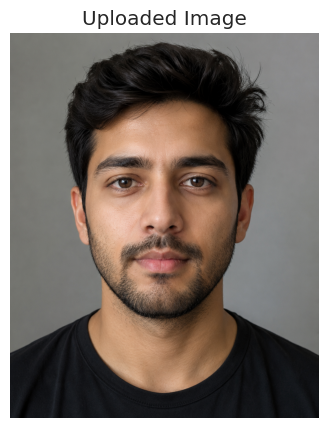

DEEPFAKE DETECTION RESULT
Prediction       : REAL
Confidence       : 56.78%
Real Probability : 56.78%
Fake Probability : 43.22%


In [128]:
# ==========================================================
# 7.2 Predict Uploaded Image
# =============

=============================================

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from io import BytesIO

# ----------------------------------------------------------
# Check if a file has been uploaded
# ----------------------------------------------------------

if len(uploader.value) == 0:
    raise Exception("Please upload an image first.")

# ----------------------------------------------------------
# Get uploaded file (ipywidgets 8.x)
# ----------------------------------------------------------

uploaded_file = uploader.value[0]

# ----------------------------------------------------------
# Read image
# ----------------------------------------------------------

image = Image.open(
    BytesIO(uploaded_file["content"])
).convert("RGB")

# ----------------------------------------------------------
# Display original image
# ----------------------------------------------------------

plt.figure(figsize=(5,5))
plt.imshow(image)
plt.axis("off")
plt.title("Uploaded Image")
plt.show()

# ----------------------------------------------------------
# Preprocess image
# ----------------------------------------------------------

image = image.resize((224,224))

img_array = np.array(image, dtype=np.float32)

img_array /= 255.0

img_array = np.expand_dims(img_array, axis=0)

# ----------------------------------------------------------
# Prediction
# ----------------------------------------------------------

prediction = model.predict(img_array, verbose=0)[0][0]

fake_probability = float(prediction)

real_probability = 1.0 - fake_probability

if fake_probability >= 0.5:
    label = "FAKE"
    confidence = fake_probability * 100
else:
    label = "REAL"
    confidence = real_probability * 100

# ----------------------------------------------------------
# Display Results
# ----------------------------------------------------------

print("="*60)
print("DEEPFAKE DETECTION RESULT")
print("="*60)

print(f"Prediction       : {label}")
print(f"Confidence       : {confidence:.2f}%")
print(f"Real Probability : {real_probability*100:.2f}%")
print(f"Fake Probability : {fake_probability*100:.2f}%")

print("="*60)

# Test on Unseen Data

In [ ]:
# ==========================================================
# Phase 5.2
# Load Trained Model & Upload Unseen Video
# ==========================================================

import os
import cv2
import time
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.models import load_model
from google.colab import files

print("="*70)
print("DEEPFAKE DETECTION - PHASE 5.2")
print("="*70)

# ----------------------------------------------------------
# Configuration
# ----------------------------------------------------------

MODEL_PATH = "EfficientNetB2_Stage1.keras"

IMAGE_SIZE = (224,224)

FRAME_SKIP = 5      # Process every 5th frame

CONFIDENCE_THRESHOLD = 0.50

print(f"Model Path            : {MODEL_PATH}")
print(f"Input Image Size      : {IMAGE_SIZE}")
print(f"Frame Skip            : {FRAME_SKIP}")
print(f"Decision Threshold    : {CONFIDENCE_THRESHOLD}")

print("="*70)

# ----------------------------------------------------------
# Load Trained Model
# ----------------------------------------------------------

print("\nLoading trained model...")

model = load_model(MODEL_PATH)

print("Model Loaded Successfully!")

print("\nModel Input Shape :")

print(model.input_shape)

print("\nModel Output Shape :")

print(model.output_shape)

print("="*70)

# ----------------------------------------------------------
# Upload Video
# ----------------------------------------------------------

print("\nUpload ONE unseen video (.mp4)\n")

uploaded = files.upload()

if len(uploaded) == 0:
    raise Exception("No video uploaded.")

VIDEO_PATH = list(uploaded.keys())[0]

print("\nUploaded Video")

print(VIDEO_PATH)

print("="*70)

# ----------------------------------------------------------
# Validate Video
# ----------------------------------------------------------

cap = cv2.VideoCapture(VIDEO_PATH)

if not cap.isOpened():
    raise Exception("Unable to open uploaded video.")

fps = cap.get(cv2.CAP_PROP_FPS)

frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))

height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

duration = frame_count / fps if fps > 0 else 0

print("Video Information")

print("-"*50)

print(f"Resolution      : {width} x {height}")

print(f"FPS             : {fps:.2f}")

print(f"Total Frames    : {frame_count}")

print(f"Duration        : {duration:.2f} sec")

print("="*70)

cap.release()

# ----------------------------------------------------------
# Create Working Directories
# ----------------------------------------------------------

OUTPUT_DIR = "Inference_Output"

FRAME_DIR = os.path.join(OUTPUT_DIR, "Frames")

FACE_DIR = os.path.join(OUTPUT_DIR, "Faces")

RESULT_DIR = os.path.join(OUTPUT_DIR, "Results")

os.makedirs(FRAME_DIR, exist_ok=True)

os.makedirs(FACE_DIR, exist_ok=True)

os.makedirs(RESULT_DIR, exist_ok=True)

print("Output folders created.")

print(FRAME_DIR)

print(FACE_DIR)

print(RESULT_DIR)

print("="*70)

# ----------------------------------------------------------
# Initialize Variables
# ----------------------------------------------------------

video_predictions = []

prediction_scores = []

processed_frames = []

detected_faces = []

frame_numbers = []

processing_start_time = time.time()

print("\nInitialization Complete.")

print("="*70)

print("Phase 5.2 Completed Successfully!")

print("\nNext Phase : 5.3 - Extract Frames & Detect Faces")

In [ ]:
!pip install retina-face

In [ ]:
# ==========================================================
# Phase 5.3
# Extract Frames & Detect Faces
# ==========================================================

from retinaface import RetinaFace

print("="*70)
print("PHASE 5.3 - FRAME EXTRACTION & FACE DETECTION")
print("="*70)

cap = cv2.VideoCapture(VIDEO_PATH)

frame_id = 0
saved_faces = 0
saved_frames = 0

while True:

    ret, frame = cap.read()

    if not ret:
        break

    # -----------------------------------------------
    # Skip frames to speed up prediction
    # -----------------------------------------------

    if frame_id % FRAME_SKIP != 0:
        frame_id += 1
        continue

    original_frame = frame.copy()

    # Save frame for visualization
    frame_path = os.path.join(
        FRAME_DIR,
        f"frame_{frame_id:05d}.jpg"
    )

    cv2.imwrite(frame_path, original_frame)

    saved_frames += 1

    try:

        detections = RetinaFace.detect_faces(original_frame)

    except Exception:

        frame_id += 1
        continue

    # -----------------------------------------------
    # No face detected
    # -----------------------------------------------

    if not isinstance(detections, dict):

        frame_id += 1
        continue

    # -----------------------------------------------
    # Process every detected face
    # -----------------------------------------------

    for key in detections.keys():

        facial_area = detections[key]["facial_area"]

        x1, y1, x2, y2 = facial_area

        x1 = max(0, x1)
        y1 = max(0, y1)

        x2 = min(original_frame.shape[1], x2)
        y2 = min(original_frame.shape[0], y2)

        face = original_frame[y1:y2, x1:x2]

        if face.size == 0:
            continue

        # -----------------------------------------------
        # Resize
        # -----------------------------------------------

        face = cv2.resize(face, IMAGE_SIZE)

        # -----------------------------------------------
        # RGB Conversion
        # -----------------------------------------------

        face = cv2.cvtColor(face, cv2.COLOR_BGR2RGB)

        # -----------------------------------------------
        # Normalize
        # (same preprocessing used during training)
        # -----------------------------------------------

        face = face.astype(np.float32) / 255.0

        # -----------------------------------------------
        # Save face image
        # -----------------------------------------------

        face_path = os.path.join(
            FACE_DIR,
            f"face_{saved_faces:05d}.jpg"
        )

        cv2.imwrite(
            face_path,
            cv2.cvtColor(
                (face * 255).astype(np.uint8),
                cv2.COLOR_RGB2BGR
            )
        )

        # -----------------------------------------------
        # Store for prediction
        # -----------------------------------------------

        detected_faces.append(face)

        processed_frames.append(original_frame)

        frame_numbers.append(frame_id)

        saved_faces += 1

    frame_id += 1

cap.release()

print("\nExtraction Completed")

print("-"*60)

print(f"Frames Read             : {frame_count}")

print(f"Frames Processed        : {saved_frames}")

print(f"Faces Detected          : {saved_faces}")

print(f"Frames Saved            : {len(processed_frames)}")

print("="*70)

# ----------------------------------------------------------
# Preview Sample Faces
# ----------------------------------------------------------

preview = min(6, len(detected_faces))

if preview > 0:

    plt.figure(figsize=(15,6))

    for i in range(preview):

        plt.subplot(2,3,i+1)

        plt.imshow(detected_faces[i])

        plt.title(f"Face {i+1}")

        plt.axis("off")

    plt.tight_layout()

    plt.show()

else:

    print("No faces detected.")

print("="*70)
print("Phase 5.3 Completed Successfully!")
print("Next Phase : 5.4 - Deepfake Prediction")

# Predict Deepfake on Unseen Video

In [ ]:
# ==========================================================
# Phase 5.4
# Predict Deepfake on Unseen Video
# ==========================================================

print("="*70)
print("PHASE 5.4 - MODEL PREDICTION")
print("="*70)

# ----------------------------------------------------------
# Safety Check
# ----------------------------------------------------------

if len(detected_faces) == 0:
    raise Exception("No faces available for prediction.")

print(f"Faces Ready For Prediction : {len(detected_faces)}")

print("="*70)

# ----------------------------------------------------------
# Prediction Variables
# ----------------------------------------------------------

prediction_scores = []

prediction_labels = []

real_count = 0

fake_count = 0

# ----------------------------------------------------------
# Predict Every Face
# ----------------------------------------------------------

for i, face in enumerate(detected_faces):

    # Model expects batch dimension
    input_image = np.expand_dims(face, axis=0)

    # Predict
    score = model.predict(input_image, verbose=0)[0][0]

    prediction_scores.append(float(score))

    # Sigmoid Output
    if score >= CONFIDENCE_THRESHOLD:

        prediction_labels.append("Fake")

        fake_count += 1

    else:

        prediction_labels.append("Real")

        real_count += 1

# ----------------------------------------------------------
# Statistics
# ----------------------------------------------------------

prediction_scores = np.array(prediction_scores)

average_probability = prediction_scores.mean()

maximum_probability = prediction_scores.max()

minimum_probability = prediction_scores.min()

std_probability = prediction_scores.std()

# ----------------------------------------------------------
# Majority Voting
# ----------------------------------------------------------

if fake_count > real_count:

    final_prediction = "DEEPFAKE"

elif real_count > fake_count:

    final_prediction = "REAL"

else:

    # Tie → Use Average Probability
    if average_probability >= CONFIDENCE_THRESHOLD:

        final_prediction = "DEEPFAKE"

    else:

        final_prediction = "REAL"

# ----------------------------------------------------------
# Final Confidence
# ----------------------------------------------------------

if final_prediction == "DEEPFAKE":

    confidence = average_probability * 100

else:

    confidence = (1 - average_probability) * 100

# ----------------------------------------------------------
# Display Summary
# ----------------------------------------------------------

print("\nPrediction Summary")

print("-"*60)

print(f"Total Faces              : {len(detected_faces)}")

print(f"Real Predictions         : {real_count}")

print(f"Fake Predictions         : {fake_count}")

print("-"*60)

print(f"Average Probability      : {average_probability:.4f}")

print(f"Maximum Probability      : {maximum_probability:.4f}")

print(f"Minimum Probability      : {minimum_probability:.4f}")

print(f"Std Deviation            : {std_probability:.4f}")

print("-"*60)

print(f"Final Prediction         : {final_prediction}")

print(f"Confidence               : {confidence:.2f}%")

print("="*70)

# ----------------------------------------------------------
# Prediction Distribution
# ----------------------------------------------------------

plt.figure(figsize=(10,5))

plt.hist(
    prediction_scores,
    bins=20
)

plt.axvline(
    CONFIDENCE_THRESHOLD,
    linestyle="--",
    linewidth=2,
    label="Threshold"
)

plt.title("Prediction Score Distribution")

plt.xlabel("Fake Probability")

plt.ylabel("Number of Faces")

plt.legend()

plt.show()

print("="*70)

# ----------------------------------------------------------
# Store Results
# ----------------------------------------------------------

results = {

    "video_name": VIDEO_PATH,

    "faces_detected": len(detected_faces),

    "real_faces": real_count,

    "fake_faces": fake_count,

    "average_probability": average_probability,

    "confidence": confidence,

    "prediction": final_prediction

}

print("Results Saved In Memory")

print("="*70)

print("Phase 5.4 Completed Successfully!")

print("\nNext Phase : 5.5 - Visualization & Final Report")

In [ ]:
# ==========================================================
# Phase 5.5
# Visualization & Final Report
# ==========================================================

import pandas as pd
import matplotlib.pyplot as plt
import cv2
import os
import time

print("="*80)
print("PHASE 5.5 - FINAL REPORT")
print("="*80)

# ----------------------------------------------------------
# Processing Time
# ----------------------------------------------------------

processing_end_time = time.time()

processing_time = processing_end_time - processing_start_time

# ----------------------------------------------------------
# Create DataFrame
# ----------------------------------------------------------

report_df = pd.DataFrame({

    "Frame Number": frame_numbers,

    "Prediction": prediction_labels,

    "Fake Probability": prediction_scores

})

csv_path = os.path.join(

    RESULT_DIR,

    "Prediction_Report.csv"

)

report_df.to_csv(csv_path,index=False)

print("Prediction report saved.")

print(csv_path)

print("="*80)

# ----------------------------------------------------------
# Display Sample Predictions
# ----------------------------------------------------------

samples = min(9,len(detected_faces))

if samples > 0:

    plt.figure(figsize=(16,16))

    for i in range(samples):

        plt.subplot(3,3,i+1)

        image = detected_faces[i]

        label = prediction_labels[i]

        score = prediction_scores[i]

        plt.imshow(image)

        plt.title(

            f"{label}\n{score:.3f}"

        )

        plt.axis("off")

    plt.tight_layout()

    plt.show()

else:

    print("No prediction images available.")

print("="*80)

# ----------------------------------------------------------
# Probability Plot
# ----------------------------------------------------------

plt.figure(figsize=(14,5))

plt.plot(

    prediction_scores,

    linewidth=2

)

plt.axhline(

    CONFIDENCE_THRESHOLD,

    linestyle="--",

    linewidth=2,

    color="red"

)

plt.title("Prediction Probability Across Frames")

plt.xlabel("Detected Face")

plt.ylabel("Fake Probability")

plt.grid(True)

plt.show()

print("="*80)

# ----------------------------------------------------------
# Pie Chart
# ----------------------------------------------------------

plt.figure(figsize=(6,6))

plt.pie(

    [real_count,fake_count],

    labels=["Real","Fake"],

    autopct="%1.1f%%",

    startangle=90

)

plt.title("Prediction Distribution")

plt.show()

print("="*80)

# ----------------------------------------------------------
# Final Report
# ----------------------------------------------------------

print()

print("="*80)

print("DEEPFAKE DETECTION REPORT")

print("="*80)

print(f"Video Name              : {VIDEO_PATH}")

print(f"Frames In Video         : {frame_count}")

print(f"Frames Processed        : {len(processed_frames)}")

print(f"Faces Detected          : {len(detected_faces)}")

print()

print(f"Real Faces              : {real_count}")

print(f"Fake Faces              : {fake_count}")

print()

print(f"Average Fake Probability: {average_probability:.4f}")

print(f"Confidence              : {confidence:.2f}%")

print()

print(f"FINAL DECISION          : {final_prediction}")

print()

print(f"Processing Time         : {processing_time:.2f} seconds")

print("="*80)

# ----------------------------------------------------------
# Save Summary
# ----------------------------------------------------------

summary = pd.DataFrame({

    "Video":[VIDEO_PATH],

    "Frames":[frame_count],

    "Processed Frames":[len(processed_frames)],

    "Faces":[len(detected_faces)],

    "Real Faces":[real_count],

    "Fake Faces":[fake_count],

    "Average Probability":[average_probability],

    "Confidence":[confidence],

    "Prediction":[final_prediction],

    "Processing Time (sec)":[processing_time]

})

summary_path = os.path.join(

    RESULT_DIR,

    "Final_Summary.csv"

)

summary.to_csv(summary_path,index=False)

print()

print("Summary saved to:")

print(summary_path)

print("="*80)

print("Inference Completed Successfully!")

print("="*80)